In [1]:
import pandas as pd

data = pd.read_csv('/Users/vladamalkina/Desktop/course.csv')
data = data.drop(columns = ['timestamp'])

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   jtbd_reason_text    1362 non-null   object
 1   main_pain           1362 non-null   object
 2   max_budget          1362 non-null   int64 
 3   max_commute_time    1362 non-null   int64 
 4   metro_priority      1362 non-null   int64 
 5   preferred_district  1362 non-null   object
 6   min_rooms           1362 non-null   int64 
 7   min_area            1362 non-null   int64 
 8   preferred_floor     1362 non-null   object
 9   property_type       1362 non-null   object
 10  need_parking        1362 non-null   object
 11  household_size      1362 non-null   int64 
 12  age_group           1362 non-null   object
 13  current_housing     1361 non-null   object
 14  marital_status      1362 non-null   object
dtypes: int64(6), object(9)
memory usage: 159.7+ KB


In [3]:
data.head()

,jtbd_reason_text,main_pain,max_budget,max_commute_time,metro_priority,preferred_district,min_rooms,min_area,preferred_floor,property_type,need_parking,household_size,age_group,current_housing,marital_status
0,Хочу жить отдельно от родителей/друзей,Долгая или неудобная дорога на работу,5760745,53,2,ЮВАО,0,41,Первый этаж допустим,"Предпочтительно новостройка, но рассмотрю втор...",Да,1,25-34,Снимаю жилье,Не женат/не замужем
1,"Съемное жилье в плохом состоянии, хочу что-то ...","Плохое состояние дома, требуется ремонт",11460529,20,4,ЮВАО,1,52,Только не первый и не последний,"Предпочтительно вторичное жилье, но рассмотрю ...",Да,1,25-34,Живу с родителями/родственниками,Не женат/не замужем
2,Хочу балкон/лоджию для отдыха,Долгая или неудобная дорога на работу,11523020,81,2,СВАО,4,98,Первый этаж допустим,"Предпочтительно вторичное жилье, но рассмотрю ...",Нет,2,35-44,Живу в своей квартире,Женат/замужем
3,Стало тесно с родственниками,"Недостаточно места, теснота",7064053,35,5,ЗАО,1,50,Первый этаж допустим,Только новостройка (сдача от застройщика),Да,1,25-34,Живу с родителями/родственниками,Не женат/не замужем
4,"Ищу квартиру в тихом районе, подальше от шума","Не нравится район, двор, инфраструктура",13190800,40,3,ЦАО,1,41,Первый этаж допустим,Только новостройка (сдача от застройщика),Нет,2,45-54,Живу в своей квартире,В разводе


### Предобработка численных признаков

In [4]:
import numpy as np

df_clean = data.copy()
k = 0

num_feat = ['max_budget', 
                'max_commute_time', 
                'min_rooms', 
                'min_area', 
                'household_size']

num_features = ['Максимальный бюджет', 
                'Максимально допустимое время на дорогу до офиса', 
                'Минимальное количество комнат', 
                'Минимальная желаемая площадь', 
                'Кол-во человек, которые будут проживать в квартире']
for i in num_feat:
    print(num_features[k])
    print('от', min(df_clean[i]), 'до', max(df_clean[i]))
    print()
    k+=1

Максимальный бюджет
от 3784158 до 38500962

Максимально допустимое время на дорогу до офиса
от 20 до 90

Минимальное количество комнат
от 0 до 4

Минимальная желаемая площадь
от 25 до 112

Кол-во человек, которые будут проживать в квартире
от 1 до 4



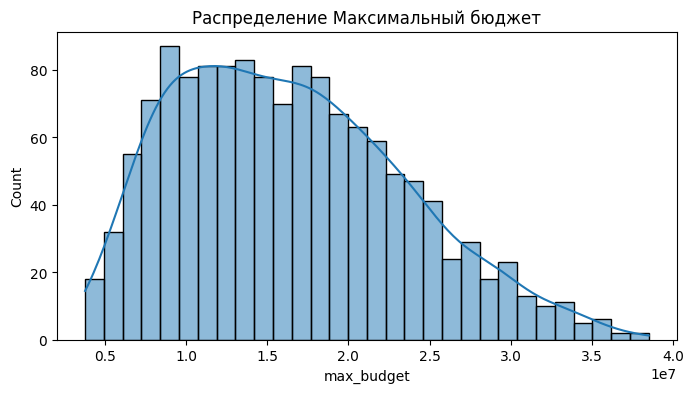

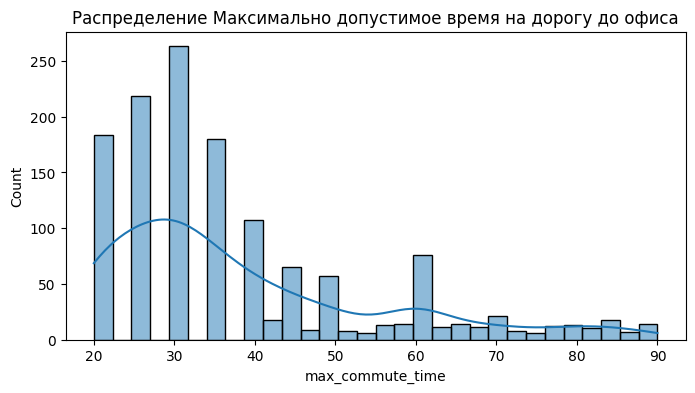

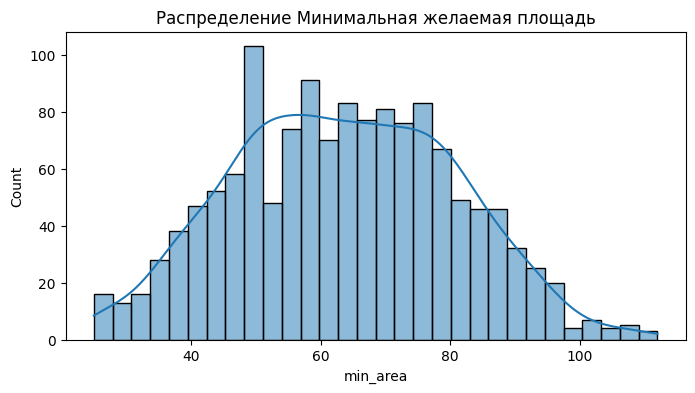

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

num_feat_continuous = ['max_budget', 'max_commute_time', 'min_area']
num_features_continuous = ['Максимальный бюджет', 'Максимально допустимое время на дорогу до офиса', 'Минимальная желаемая площадь']

k = 0
for feature in num_feat_continuous:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[feature], bins=30, kde=True)
    plt.title(f'Распределение {num_features_continuous[k]}')
    plt.show()
    k += 1

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   jtbd_reason_text    1362 non-null   object
 1   main_pain           1362 non-null   object
 2   max_budget          1362 non-null   int64 
 3   max_commute_time    1362 non-null   int64 
 4   metro_priority      1362 non-null   int64 
 5   preferred_district  1362 non-null   object
 6   min_rooms           1362 non-null   int64 
 7   min_area            1362 non-null   int64 
 8   preferred_floor     1362 non-null   object
 9   property_type       1362 non-null   object
 10  need_parking        1362 non-null   object
 11  household_size      1362 non-null   int64 
 12  age_group           1362 non-null   object
 13  current_housing     1361 non-null   object
 14  marital_status      1362 non-null   object
dtypes: int64(6), object(9)
memory usage: 159.7+ KB


### предобработка metro_priority

Частотное распределение metro_priority:
                Количество  Процент, %
metro_priority                        
2                      143       10.50
3                      235       17.25
4                      515       37.81
5                      469       34.43


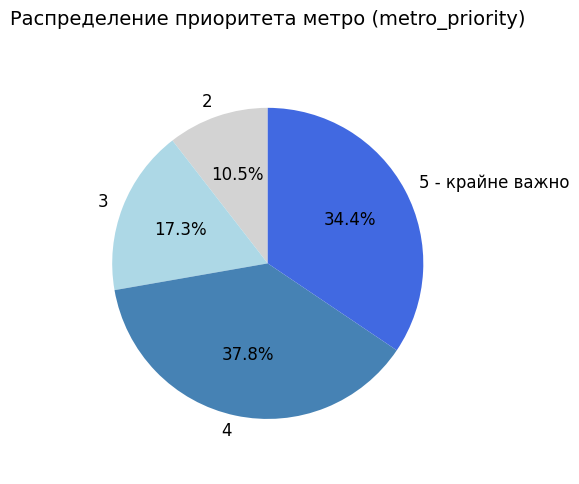

Частотное распределение минимального количества комнат (min_rooms):
           Количество  Процент, %
min_rooms                        
0                 148       10.87
1                 437       32.09
2                 465       34.14
3                 266       19.53
4                  46        3.38



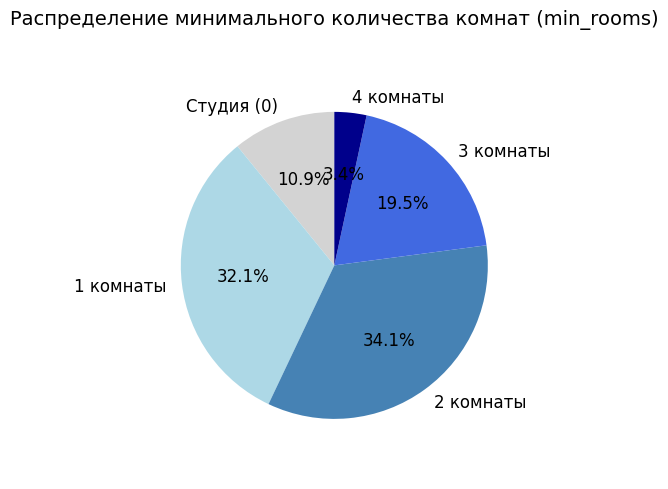

In [7]:
frequency_table = df_clean['metro_priority'].value_counts().sort_index()
percentage_table = (df_clean['metro_priority'].value_counts(normalize=True).sort_index() * 100).round(2)

summary_table = pd.DataFrame({
    'Количество': frequency_table,
    'Процент, %': percentage_table
})
print("Частотное распределение metro_priority:")
print(summary_table)

plt.figure(figsize=(5, 5))
labels = ['2', '3', '4', '5 - крайне важно']
colors = ['lightgray', 'lightblue', 'steelblue', 'royalblue', 'darkblue']

wedges, texts, autotexts = plt.pie(frequency_table, labels=labels, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 12})

plt.title('Распределение приоритета метро (metro_priority)', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Частотное распределение min_rooms
frequency_table_rooms = df_clean['min_rooms'].value_counts().sort_index()
percentage_table_rooms = (df_clean['min_rooms'].value_counts(normalize=True).sort_index() * 100).round(2)

# Сводная таблица
summary_table_rooms = pd.DataFrame({
    'Количество': frequency_table_rooms,
    'Процент, %': percentage_table_rooms
})
print("Частотное распределение минимального количества комнат (min_rooms):")
print(summary_table_rooms)
print()

# Построение круговой диаграммы
plt.figure(figsize=(5, 5))

# Формируем подписи: студия (0), 1 комната, 2 комнаты, 3 комнаты, 4 комнаты
labels_rooms = []
for val in frequency_table_rooms.index:
    if val == 0:
        labels_rooms.append('Студия (0)')
    else:
        labels_rooms.append(f'{val} комнаты' if val <= 4 else f'{val}+ комнат')

colors_rooms = ['lightgray', 'lightblue', 'steelblue', 'royalblue', 'darkblue', 'purple']

plt.pie(frequency_table_rooms.values, labels=labels_rooms, colors=colors_rooms[:len(frequency_table_rooms)],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Распределение минимального количества комнат (min_rooms)', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

Частотное распределение количества проживающих (household_size):
                Количество  Процент, %
household_size                        
1                      418       30.69
2                      411       30.18
3                      414       30.40
4                      119        8.74



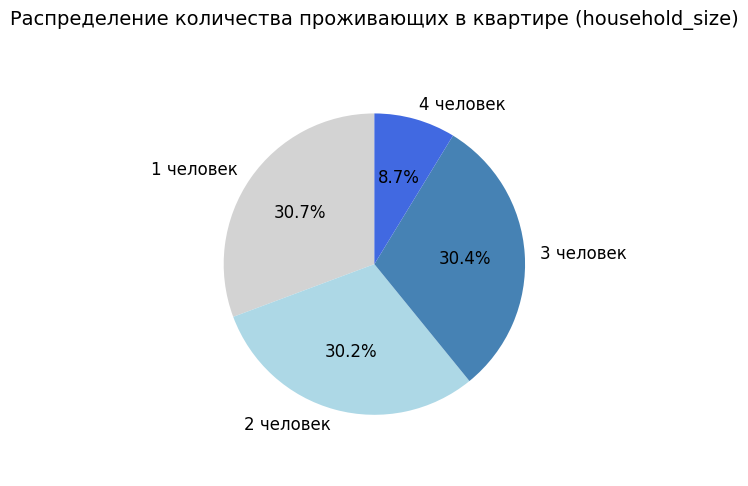

In [8]:
# Частотное распределение household_size
frequency_table_household = df_clean['household_size'].value_counts().sort_index()
percentage_table_household = (df_clean['household_size'].value_counts(normalize=True).sort_index() * 100).round(2)

# Сводная таблица
summary_table_household = pd.DataFrame({
    'Количество': frequency_table_household,
    'Процент, %': percentage_table_household
})
print("Частотное распределение количества проживающих (household_size):")
print(summary_table_household)
print()

# Построение круговой диаграммы
plt.figure(figsize=(5, 5))

labels_household = [f'{val} человек' if val <= 4 else f'{val}+ человек' for val in frequency_table_household.index]
colors_household = ['lightgray', 'lightblue', 'steelblue', 'royalblue', 'darkblue']

plt.pie(frequency_table_household.values, labels=labels_household, colors=colors_household[:len(frequency_table_household)],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Распределение количества проживающих в квартире (household_size)', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

### предобработка категориальные признаки
preferred_district

preferred_floor

property_type    

need_parking    

age_group 

current_housing

marital_status

In [9]:
cat_cols = ['preferred_district', 'preferred_floor', 'property_type',
    'need_parking', 'age_group', 'current_housing', 'marital_status']

cat_feat = ['Предпочитаемый округ', 'Предпочитаемый этаж', 'Новостройка или вторичное жилье',
    'Необходимость парковки', 'Возраст', 
            'Описание текущей жилищной ситуации', 'Семейное положение']

In [10]:
df = df_clean

In [11]:
# Обработка пропуска в 'current_housing' (заполним модой - самым частым значением)
housing = df['current_housing'].mode()[0]
df['current_housing'].fillna(housing, inplace=True)
print(f"\nПропуск в 'current_housing' заполнен значением: '{housing}'")


Пропуск в 'current_housing' заполнен значением: 'Живу в своей квартире'


/var/folders/vg/37s_f8fn3c3fqdmpkfq0wq180000gn/T/ipykernel_1562/1491215787.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['current_housing'].fillna(housing, inplace=True)


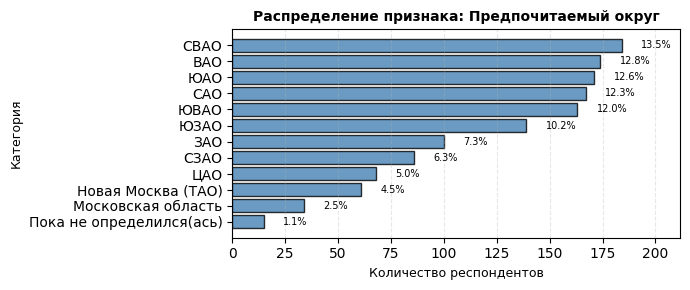

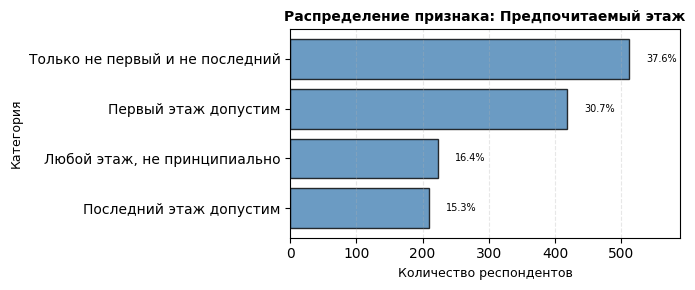

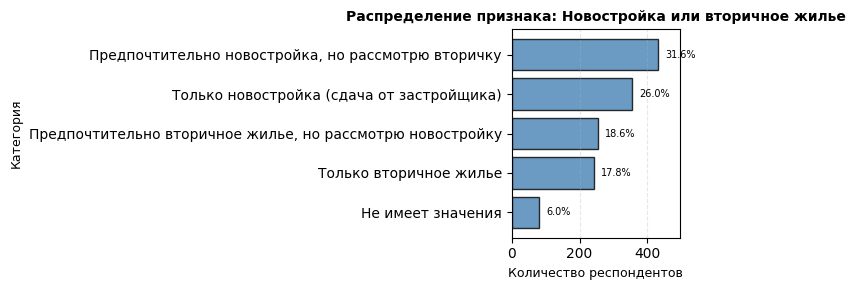


Распределение признака: Необходимость парковки
  • Нет: 686 чел. (50.4%)
  • Да: 676 чел. (49.6%)


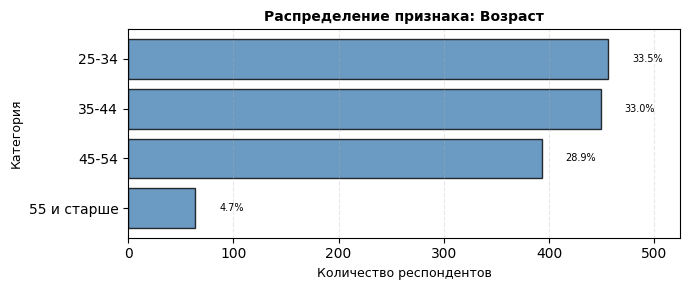

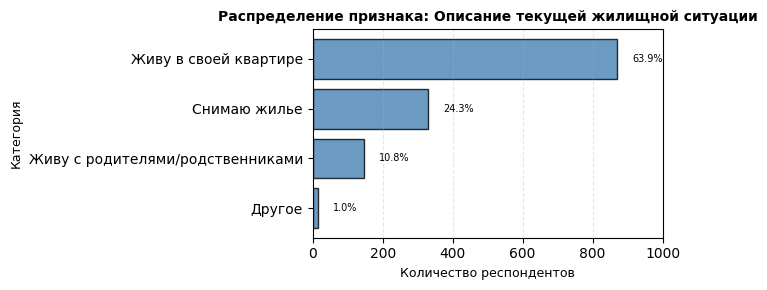

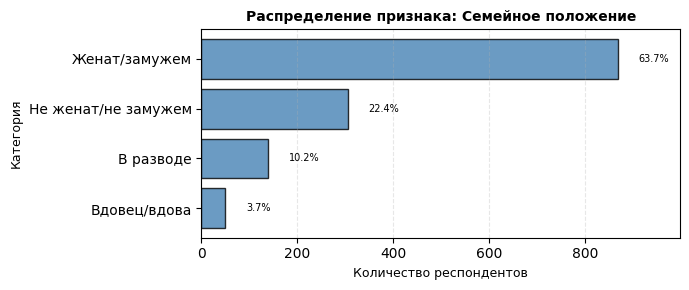

In [12]:
binary_features = ['need_parking']

k = 0
for feature in cat_cols:
    counts = df[feature].value_counts()
    percentages = (counts / counts.sum() * 100).round(1)
    
    # Если признак бинарный (2 категории) и в списке исключений - выводим текстом
    if feature in binary_features:
        print(f"\n{'='*50}")
        print(f"Распределение признака: {cat_feat[k]}")
        for val, count in counts.items():
            print(f"  • {val}: {count} чел. ({percentages[val]}%)")
        print(f"{'='*50}")
        k += 1
        continue
    
    # Для остальных признаков строим графики
    plot_data = pd.DataFrame({
        'Категория': counts.index,
        'Количество': counts.values,
        'Процент': percentages.values
    }).sort_values('Количество', ascending=True)
    
    plt.figure(figsize=(7, max(3, len(counts) * 0.25)))
    
    bars = plt.barh(plot_data['Категория'], plot_data['Количество'], 
                    color='steelblue', edgecolor='black', alpha=0.8)
    
    max_count = plot_data['Количество'].max()
    offset = max_count * 0.05
    
    for bar, percent in zip(bars, plot_data['Процент']):
        plt.text(bar.get_width() + offset, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{percent}%', va='center', fontsize=7)
    
    plt.xlabel('Количество респондентов', fontsize=9)
    plt.ylabel('Категория', fontsize=9)
    plt.title(f'Распределение признака: {cat_feat[k]}', fontsize=10, fontweight='bold')
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.xlim(0, max_count * 1.15)
    
    plt.tight_layout()
    plt.show()
    k += 1

### Анализ данных

### 1. Построение KNN

K     Метод                MAE (руб)       RMSE (руб)      R²        
5     Без весов               4,537,348 руб     5,712,488 руб     0.340
5     С весами (LR)           4,180,986 руб     5,202,011 руб     0.453
----------------------------------------------------------------------
10    Без весов               4,357,160 руб     5,444,683 руб     0.401
10    С весами (LR)           4,091,513 руб     5,002,968 руб     0.494
----------------------------------------------------------------------
15    Без весов               4,300,861 руб     5,336,136 руб     0.424
15    С весами (LR)           4,162,317 руб     5,016,765 руб     0.491
----------------------------------------------------------------------


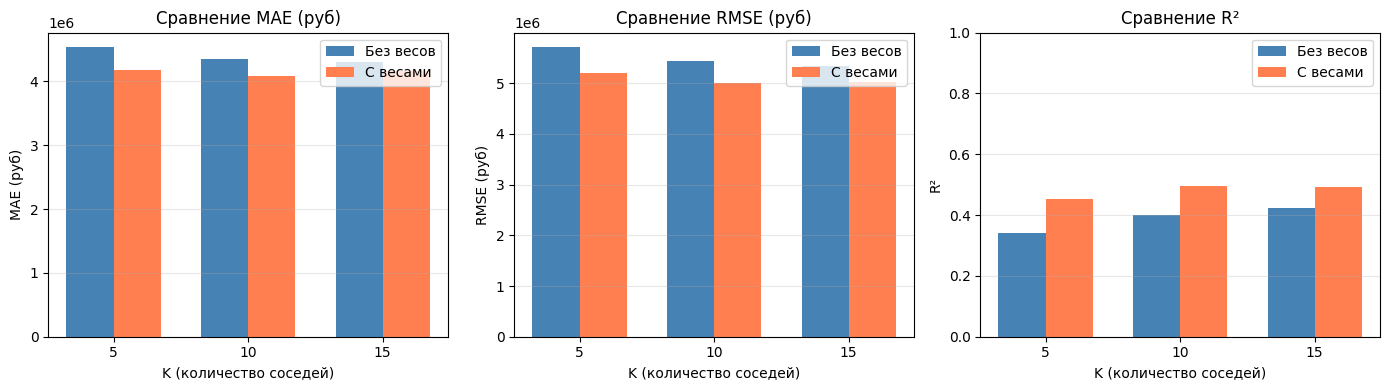

Лучший результат без весов: K=15, R2=0.424
Лучший результат с весами: K=10, R2=0.494

KNN С ВЕСАМИ работает лучше на 16.4%
Наилучший K = 10


In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = df.drop('max_budget', axis=1)
y = df['max_budget']

categorical_features = ['jtbd_reason_text', 'main_pain', 'preferred_district', 
                        'preferred_floor', 'property_type', 'need_parking', 
                        'age_group', 'current_housing', 'marital_status']
numeric_features = ['max_commute_time', 'metro_priority', 'min_rooms', 
                    'min_area', 'household_size']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)  # sparse_output=False
])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Получаем веса из линейной регрессии
lr = LinearRegression()
lr.fit(X_train, y_train)

# Нормализуем веса
feature_scales = np.sqrt(np.abs(lr.coef_) / np.abs(lr.coef_).mean())

# Применяем веса
X_train_weighted = X_train * feature_scales
X_test_weighted = X_test * feature_scales

# Сравнение для разных K
k_values = [5, 10, 15]
results = []

print(f"{'K':<5} {'Метод':<20} {'MAE (руб)':<15} {'RMSE (руб)':<15} {'R²':<10}")

for k in k_values:
    # Без весов
    knn_without = KNeighborsRegressor(n_neighbors=k)
    knn_without.fit(X_train, y_train)
    y_pred_without = knn_without.predict(X_test)
    
    mae_without = mean_absolute_error(y_test, y_pred_without)
    rmse_without = np.sqrt(mean_squared_error(y_test, y_pred_without))
    r2_without = r2_score(y_test, y_pred_without)
    
    # С весами
    knn_with = KNeighborsRegressor(n_neighbors=k)
    knn_with.fit(X_train_weighted, y_train)
    y_pred_with = knn_with.predict(X_test_weighted)
    
    mae_with = mean_absolute_error(y_test, y_pred_with)
    rmse_with = np.sqrt(mean_squared_error(y_test, y_pred_with))
    r2_with = r2_score(y_test, y_pred_with)
    
    results.append({
        'k': k,
        'without_mae': mae_without, 'without_rmse': rmse_without, 'without_r2': r2_without,
        'with_mae': mae_with, 'with_rmse': rmse_with, 'with_r2': r2_with
    })
    
    print(f"{k:<5} {'Без весов':<20} {mae_without:>12,.0f} руб  {rmse_without:>12,.0f} руб  {r2_without:>8.3f}")
    print(f"{k:<5} {'С весами (LR)':<20} {mae_with:>12,.0f} руб  {rmse_with:>12,.0f} руб  {r2_with:>8.3f}")
    print("-" * 70)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, (title, metric) in enumerate([('MAE (руб)', 'mae'), ('RMSE (руб)', 'rmse'), ('R²', 'r2')]):
    without_vals = [r[f'without_{metric}'] for r in results]
    with_vals = [r[f'with_{metric}'] for r in results]
    
    x = range(len(k_values))
    width = 0.35
    
    axes[idx].bar([i - width/2 for i in x], without_vals, width, label='Без весов', color='steelblue')
    axes[idx].bar([i + width/2 for i in x], with_vals, width, label='С весами', color='coral')
    
    axes[idx].set_xlabel('K (количество соседей)')
    axes[idx].set_ylabel(title)
    axes[idx].set_title(f'Сравнение {title}')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(k_values)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    if metric == 'r2':
        axes[idx].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Выводы
best_without_k = k_values[np.argmax([r['without_r2'] for r in results])]
best_with_k = k_values[np.argmax([r['with_r2'] for r in results])]
best_without_r2 = max([r['without_r2'] for r in results])
best_with_r2 = max([r['with_r2'] for r in results])

print(f"Лучший результат без весов: K={best_without_k}, R2={best_without_r2:.3f}")
print(f"Лучший результат с весами: K={best_with_k}, R2={best_with_r2:.3f}")

if best_with_r2 > best_without_r2:
    improvement = (best_with_r2 - best_without_r2) / best_without_r2 * 100
    print(f"\nKNN С ВЕСАМИ работает лучше на {improvement:.1f}%")
    print(f"Наилучший K = {best_with_k}")
else:
    improvement = (best_without_r2 - best_with_r2) / best_with_r2 * 100
    print(f"\nKNN БЕЗ ВЕСОВ работает лучше на {improvement:.1f}%")
    print(f"Наилучший K = {best_without_k}")

### 2. Профиль клиента


Распределение main_pain:
                                         Количество  Процент
main_pain                                                   
Плохое состояние дома, требуется ремонт         283     20.8
Не нравится район, двор, инфраструктура         274     20.1
Долгая или неудобная дорога на работу           244     17.9
Высокие расходы (аренда, ЖКХ)                   205     15.1
Недостаточно места, теснота                     168     12.3
Другое                                          104      7.6
Неудобная планировка                             84      6.2



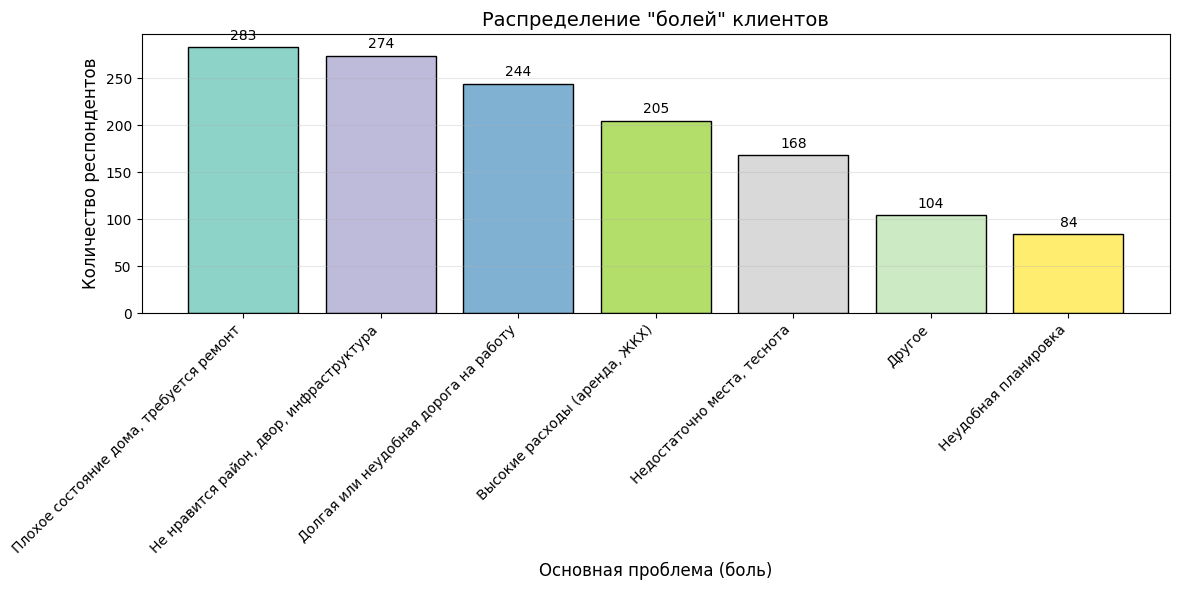

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_analysis = df.copy()

print("\nРаспределение main_pain:")
pain_distribution = df_analysis['main_pain'].value_counts()
pain_percentage = df_analysis['main_pain'].value_counts(normalize=True) * 100

pain_stats = pd.DataFrame({
    'Количество': pain_distribution,
    'Процент': pain_percentage.round(1)
})
print(pain_stats)
print()

plt.figure(figsize=(12, 6))
pain_counts = df_analysis['main_pain'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(pain_counts)))
bars = plt.bar(pain_counts.index, pain_counts.values, color=colors, edgecolor='black')

plt.xlabel('Основная проблема (боль)', fontsize=12)
plt.ylabel('Количество респондентов', fontsize=12)
plt.title('Распределение "болей" клиентов', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, pain_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/var/folders/vg/37s_f8fn3c3fqdmpkfq0wq180000gn/T/ipykernel_1562/4205987219.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(data)))


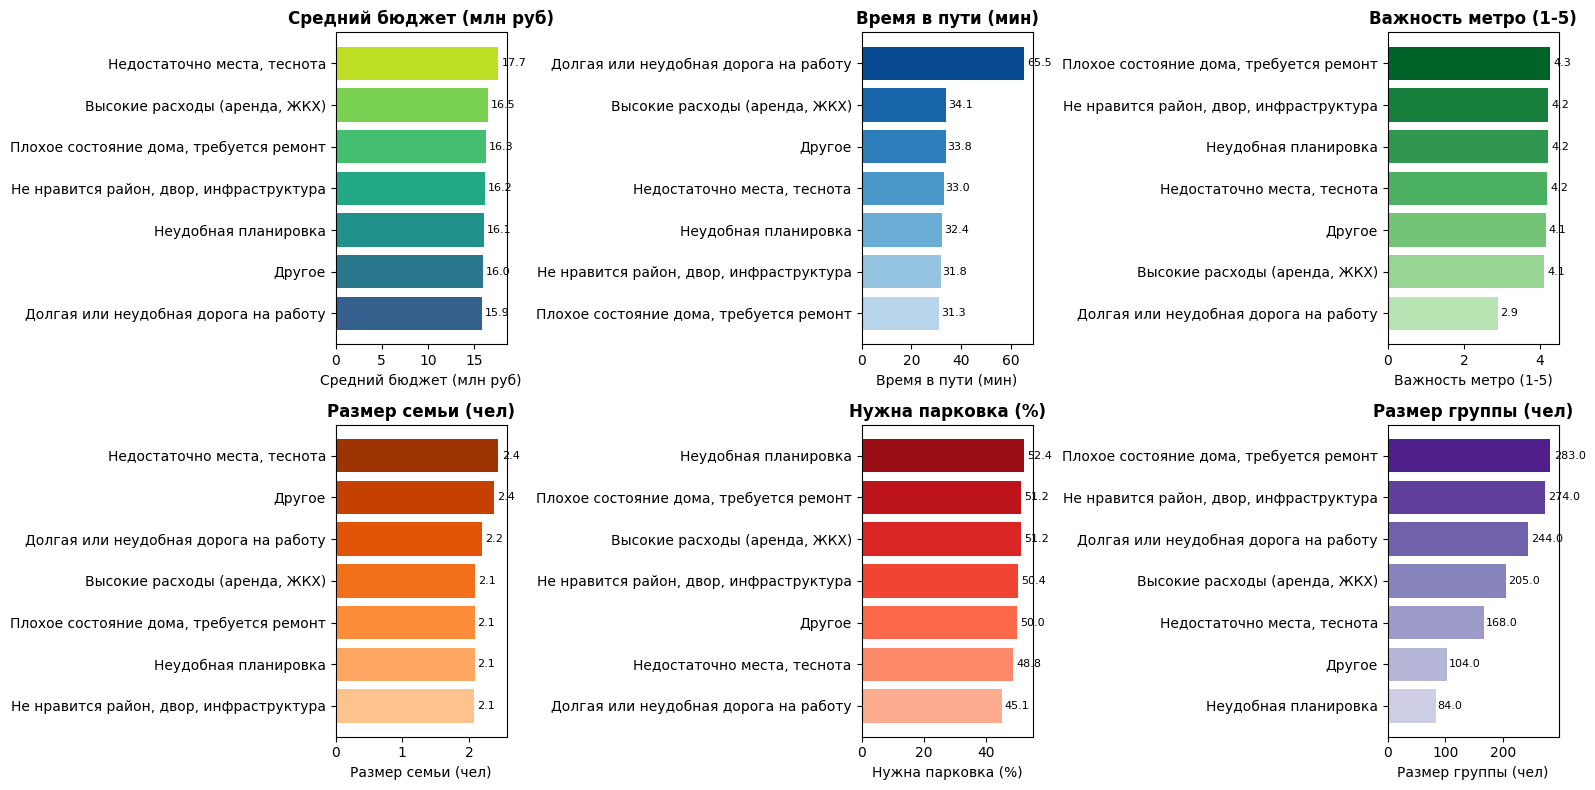


Общая статистика по всем группам:
  • Бюджет (млн руб): 15.9–17.7 (ср=16.4)
  • Время в пути (мин): 31.3–65.5 (ср=37.4)
  • Важность метро: 2.9–4.3 (ср=4.0)
  • Размер семьи: 2.1–2.4 (ср=2.2)
  • Парковка (%): 45.1–52.4 (ср=49.9)

Группы-рекордсмены:
  Самый высокий бюджет: Недостаточно места, теснота (17.7 млн руб)
  Самый низкий бюджет: Долгая или неудобная дорога на работу (15.9 млн руб)
  Готова дольше всех ехать: Долгая или неудобная дорога на работу (65.5 мин)
  Нетерпеливые (макс 30 мин): Плохое состояние дома, требуется ремонт (31.3 мин)
  Метро критично: Плохое состояние дома, требуется ремонт (4.3 /5)
  Метро не важно: Долгая или неудобная дорога на работу (2.9 /5)
  Самая большая семья: Недостаточно места, теснота (2.4 чел)
  Одиночки: Не нравится район, двор, инфраструктура (2.1 чел)
  Парковка: Неудобная планировка (52.4 %)
  Парковка не нужна: Долгая или неудобная дорога на работу (45.1 %)

Анализ категориальных признаков:
Возраст: преобладает 25-34 (4/7 групп)
Жильё: ча

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Профили клиентов по боли
pains = df_analysis['main_pain'].unique()
profiles = []

for pain in pains:
    group = df_analysis[df_analysis['main_pain'] == pain]
    other = df_analysis[df_analysis['main_pain'] != pain]
    
    profiles.append({
        'pain': pain,
        'size': len(group),
        'budget': group['max_budget'].mean() / 1e6,  # млн руб
        'commute': group['max_commute_time'].mean(),
        'metro': group['metro_priority'].mean(),
        'household': group['household_size'].mean(),
        'parking': (group['need_parking'] == 'Да').mean() * 100,
        'age': group['age_group'].mode()[0],
        'housing': group['current_housing'].mode()[0],
        'marital': group['marital_status'].mode()[0],
        'floor': group['preferred_floor'].mode()[0],
        'property': group['property_type'].mode()[0],
        'top_districts': ', '.join(group['preferred_district'].value_counts(normalize=True).head(2).index)
    })

profile_df = pd.DataFrame(profiles)

# Визуализация ключевых метрик
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = [
    ('budget', 'Средний бюджет (млн руб)', axes[0,0], 'viridis'),
    ('commute', 'Время в пути (мин)', axes[0,1], 'Blues'),
    ('metro', 'Важность метро (1-5)', axes[0,2], 'Greens'),
    ('household', 'Размер семьи (чел)', axes[1,0], 'Oranges'),
    ('parking', 'Нужна парковка (%)', axes[1,1], 'Reds'),
    ('size', 'Размер группы (чел)', axes[1,2], 'Purples')
]

for col, title, ax, cmap in metrics:
    data = profile_df.sort_values(col)
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, len(data)))
    bars = ax.barh(data['pain'], data[col], color=colors)
    ax.set_xlabel(title)
    ax.set_title(title, fontweight='bold')
    
    # Добавляем значения на бары
    for bar, val in zip(bars, data[col]):
        ax.text(val + bar.get_width()*0.02, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


# Статистика по всем группам
print("\nОбщая статистика по всем группам:")
stats_summary = {
    'Бюджет (млн руб)': profile_df['budget'],
    'Время в пути (мин)': profile_df['commute'],
    'Важность метро': profile_df['metro'],
    'Размер семьи': profile_df['household'],
    'Парковка (%)': profile_df['parking']
}

for metric, values in stats_summary.items():
    print(f"  • {metric}: {values.min():.1f}–{values.max():.1f} (ср={values.mean():.1f})")

# Поиск аномалий и экстремумов
print("\nГруппы-рекордсмены:")
records = [
    ('Самый высокий бюджет', 'budget', 'max', 'млн руб'),
    ('Самый низкий бюджет', 'budget', 'min', 'млн руб'),
    ('Готова дольше всех ехать', 'commute', 'max', 'мин'),
    ('Нетерпеливые (макс 30 мин)', 'commute', 'min', 'мин'),
    ('Метро критично', 'metro', 'max', '/5'),
    ('Метро не важно', 'metro', 'min', '/5'),
    ('Самая большая семья', 'household', 'max', 'чел'),
    ('Одиночки', 'household', 'min', 'чел'),
    ('Парковка', 'parking', 'max', '%'),
    ('Парковка не нужна', 'parking', 'min', '%')
]

for desc, col, mode, unit in records:
    if mode == 'max':
        val = profile_df[col].max()
        pain = profile_df[profile_df[col] == val]['pain'].values[0]
    else:
        val = profile_df[col].min()
        pain = profile_df[profile_df[col] == val]['pain'].values[0]
    print(f"  {desc}: {pain} ({val:.1f} {unit})")

# Категориальные признаки - что общего и что разного
print("\nАнализ категориальных признаков:")

# Считаем моду по всем группам
age_modes = profile_df['age'].value_counts()
housing_modes = profile_df['housing'].value_counts()
marital_modes = profile_df['marital'].value_counts()
floor_modes = profile_df['floor'].value_counts()
property_modes = profile_df['property'].value_counts()

print(f"Возраст: преобладает {age_modes.index[0]} ({age_modes.iloc[0]}/{len(profile_df)} групп)")
print(f"Жильё: чаще всего {housing_modes.index[0]} ({housing_modes.iloc[0]}/{len(profile_df)} групп)")
print(f"Семья: доминирует {marital_modes.index[0]} ({marital_modes.iloc[0]}/{len(profile_df)} групп)")
print(f"Этаж: большинство выбирает {floor_modes.index[0]} ({floor_modes.iloc[0]}/{len(profile_df)} групп)")
print(f"Тип жилья: популярнее {property_modes.index[0]} ({property_modes.iloc[0]}/{len(profile_df)} групп)")

# Какие группы отличаются
print("\nОтличие групп:")

# Находим группу с уникальными характеристиками
for col in ['age', 'housing', 'marital', 'floor', 'property']:
    unique_vals = profile_df[col].value_counts()
    if len(unique_vals) > 1:
        minority = unique_vals.index[-1] if len(unique_vals) > 1 else None
        if minority:
            pain = profile_df[profile_df[col] == minority]['pain'].values
            if len(pain) > 0:
                print(f"  • {col}: только у {pain[0]}: {minority} (у остальных {unique_vals.index[0]})")

# Топ-районы по группам
print("\nПредпочитаемые районы:")
for _, row in profile_df.iterrows():
    print(f"  {row['pain']}: {row['top_districts']}")

# Самый большой разброс
max_variance_col = max(stats_summary.keys(), 
                       key=lambda x: stats_summary[x].std() / stats_summary[x].mean())
print(f"Самый сильный разброс между группами — по {max_variance_col}")
print(f"     (от {stats_summary[max_variance_col].min():.1f} до {stats_summary[max_variance_col].max():.1f})")

# Самая стабильная метрика
min_variance_col = min(stats_summary.keys(), 
                       key=lambda x: stats_summary[x].std() / stats_summary[x].mean())
print(f"\nСамый стабильный параметр — {min_variance_col}")
print(f"     (все группы в диапазоне {stats_summary[min_variance_col].min():.1f}-{stats_summary[min_variance_col].max():.1f})")

# Группа, которая больше всего выделяется
profile_df['zscore'] = (profile_df['budget'] - profile_df['budget'].mean()) / profile_df['budget'].std()
outlier = profile_df.loc[profile_df['zscore'].abs().idxmax()]
if outlier['zscore'] > 1:
    print(f"\nЯвно выделяется группа «{outlier['pain']}»:")
    print(f"     Бюджет {outlier['budget']:.1f} млн (средний {profile_df['budget'].mean():.1f} млн)")
    print(f"     Семья {outlier['household']:.1f} чел (средний {profile_df['household'].mean():.1f})")
    print(f"     Парковка {outlier['parking']:.0f}% (средняя {profile_df['parking'].mean():.0f}%)")

### 3. Выявление противоречий

In [16]:
import pandas as pd
import numpy as np

df_analysis = df.copy()

housing = df_analysis['current_housing'].mode()[0]
df_analysis['current_housing'].fillna(housing, inplace=True)

# Расчет дополнительных метрик
df_analysis['budget_per_person'] = df_analysis['max_budget'] / df_analysis['household_size']
df_analysis['area_per_person'] = df_analysis['min_area'] / df_analysis['household_size']

# Пороговые значения
budget_25 = df_analysis['budget_per_person'].quantile(0.25)
budget_75 = df_analysis['budget_per_person'].quantile(0.75)
area_25 = df_analysis['area_per_person'].quantile(0.25)
area_75 = df_analysis['area_per_person'].quantile(0.75)
commute_median = df_analysis['max_commute_time'].median()

# Противоречия (сплошная нумерация 1-17)
contradictions = {}

# 1-5. Метро и транспорт
contradictions[1] = ('Дорога важна, но метро не важно (1-2)', (df_analysis['main_pain'] == "Долгая или неудобная дорога на работу") & (df_analysis['metro_priority'] <= 2))
contradictions[2] = ('Дорога важна, но метро средне (3)', (df_analysis['main_pain'] == "Долгая или неудобная дорога на работу") & (df_analysis['metro_priority'] == 3))
contradictions[3] = ('Не нравится район, но метро не важно (1-2)', (df_analysis['main_pain'] == "Не нравится район, двор, инфраструктура") & (df_analysis['metro_priority'] <= 2))
contradictions[4] = ('Метро критично (5), но проблема не в дороге', (df_analysis['main_pain'] != "Долгая или неудобная дорога на работу") & (df_analysis['metro_priority'] == 5))
contradictions[5] = ('Метро не важно (1), но дорога указана как проблема', (df_analysis['main_pain'] == "Долгая или неудобная дорога на работу") & (df_analysis['metro_priority'] == 1))

# 6-8. Бюджет и площадь
contradictions[6] = ('Низкий бюджет/чел (<25p), но хочет большую площадь (>75p)', (df_analysis['budget_per_person'] < budget_25) & (df_analysis['area_per_person'] > area_75))
contradictions[7] = ('Высокий бюджет (>75p), но хочет маленькую площадь (<25p)', (df_analysis['budget_per_person'] > budget_75) & (df_analysis['area_per_person'] < area_25))
contradictions[8] = ('Бюджет ниже среднего, но хочет много комнат (>=4)', (df_analysis['budget_per_person'] < budget_25) & (df_analysis['min_rooms'] >= 4))

# 9-11. Тип жилья
contradictions[9] = ('Жалуется на состояние, но выбирает вторичку', (df_analysis['main_pain'] == "Плохое состояние дома, требуется ремонт") & (df_analysis['property_type'].str.contains("вторичка|вторичное", na=False, case=False)))
contradictions[10] = ('Не нравится район, но не выбирает новостройку', (df_analysis['main_pain'] == "Не нравится район, двор, инфраструктура") & (~df_analysis['property_type'].str.contains("новостройка", na=False, case=False)))
contradictions[11] = ('Хочет парковку, но выбирает старый фонд', (df_analysis['need_parking'] == "Да") & (df_analysis['property_type'].str.contains("вторичка|хрущёвка|старый", na=False, case=False)))

# 12-13. Время в пути
contradictions[12] = ('Жалуется на дорогу, но готов ехать > медианы', (df_analysis['main_pain'] == "Долгая или неудобная дорога на работу") & (df_analysis['max_commute_time'] > commute_median))
contradictions[13] = ('Не жалуется на дорогу, но хочет ехать <15 мин', (df_analysis['main_pain'] != "Долгая или неудобная дорога на работу") & (df_analysis['max_commute_time'] <= 15) & (df_analysis['max_commute_time'].notna()))

# 14-15. Размер семьи
contradictions[14] = ('Большая семья (>3 чел), но хочет мало комнат (1-2)', (df_analysis['household_size'] >= 4) & (df_analysis['min_rooms'] <= 2))
contradictions[15] = ('Одиночка (1 чел), но хочет много комнат (>3)', (df_analysis['household_size'] == 1) & (df_analysis['min_rooms'] >= 4))

# 16-17. Этаж
contradictions[16] = ('Хочет последний этаж, но жалуется на состояние дома', (df_analysis['preferred_floor'].str.contains("последний", na=False)) & (df_analysis['main_pain'] == "Плохое состояние дома, требуется ремонт"))
contradictions[17] = ('Против первого этажа, но нужна парковка', (df_analysis['preferred_floor'].str.contains("не первый", na=False)) & (df_analysis['need_parking'] == "Да"))

# Вывод
print(f"Всего респондентов: {len(df_analysis)}")

results = {}
all_mask = pd.Series([False] * len(df_analysis))

for num in range(1, 18):
    name, condition = contradictions[num]
    cnt = condition.sum()
    results[name] = cnt
    all_mask |= condition
    if cnt > 0:
        print(f"{num}. {name}: {cnt} ({cnt/len(df_analysis)*100:.1f}%)")
    else:
        print(f"{num}. {name}: 0 (0.0%)")
    print()

print("-" * 60)
print(f"Всего противоречий (с учетом повторений): {sum(results.values())}")
print(f"Респондентов с хотя бы одним противоречием: {all_mask.sum()} ({all_mask.sum()/len(df_analysis)*100:.1f}%)")
print(f"Среднее число противоречий на одного такого респондента: {sum(results.values())/all_mask.sum():.2f}")

most_common_name = max(results, key=results.get)
most_common_num = [num for num, (name, _) in contradictions.items() if name == most_common_name][0]
print(f"Самое частое противоречие: #{most_common_num} {most_common_name} ({results[most_common_name]} чел.)")

Всего респондентов: 1362
1. Дорога важна, но метро не важно (1-2): 93 (6.8%)

2. Дорога важна, но метро средне (3): 91 (6.7%)

3. Не нравится район, но метро не важно (1-2): 10 (0.7%)

4. Метро критично (5), но проблема не в дороге: 463 (34.0%)

5. Метро не важно (1), но дорога указана как проблема: 0 (0.0%)

6. Низкий бюджет/чел (<25p), но хочет большую площадь (>75p): 26 (1.9%)

7. Высокий бюджет (>75p), но хочет маленькую площадь (<25p): 14 (1.0%)

8. Бюджет ниже среднего, но хочет много комнат (>=4): 17 (1.2%)

9. Жалуется на состояние, но выбирает вторичку: 118 (8.7%)

10. Не нравится район, но не выбирает новостройку: 115 (8.4%)

11. Хочет парковку, но выбирает старый фонд: 0 (0.0%)

12. Жалуется на дорогу, но готов ехать > медианы: 244 (17.9%)

13. Не жалуется на дорогу, но хочет ехать <15 мин: 0 (0.0%)

14. Большая семья (>3 чел), но хочет мало комнат (1-2): 13 (1.0%)

15. Одиночка (1 чел), но хочет много комнат (>3): 6 (0.4%)

16. Хочет последний этаж, но жалуется на состояние

/var/folders/vg/37s_f8fn3c3fqdmpkfq0wq180000gn/T/ipykernel_1562/1978049654.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_analysis['current_housing'].fillna(housing, inplace=True)


### 4. Построение Random Forest, XGBoost, LightGBM и CatBoost


 1. РАЗБИЕНИЕ БЮДЖЕТА НА КАТЕГОРИИ

Статистика бюджета:
  Минимум: 3,784,158 руб
  25-й перцентиль: 10,723,830 руб
  Медиана: 15,582,448 руб
  75-й перцентиль: 21,112,177 руб
  Максимум: 38,500,962 руб

Распределение категорий бюджета:
  A_Эконом (<7M): 88 чел (6.5%)
  B_Стандарт (7-10M): 206 чел (15.1%)
  C_Комфорт (10-15M): 338 чел (24.8%)
  D_Бизнес (15-25M): 562 чел (41.3%)
  E_Премиум (>25M): 168 чел (12.3%)


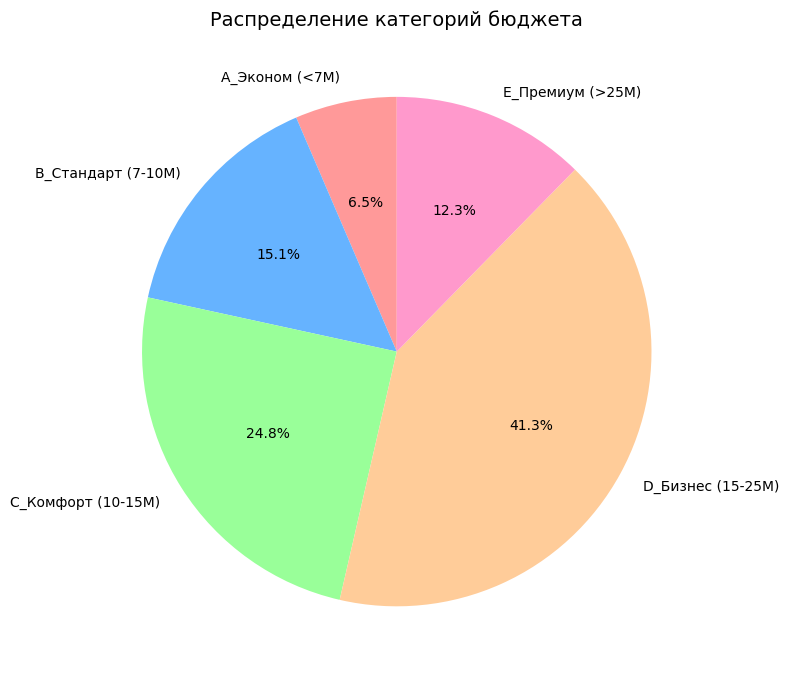

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb

df_model = df.copy()
housing = df_model['current_housing'].mode()[0]
df_model['current_housing'].fillna(housing, inplace=True)

print("\n 1. РАЗБИЕНИЕ БЮДЖЕТА НА КАТЕГОРИИ")

budget_stats = df_model['max_budget'].describe()
print(f"\nСтатистика бюджета:")
print(f"  Минимум: {budget_stats['min']:,.0f} руб")
print(f"  25-й перцентиль: {budget_stats['25%']:,.0f} руб")
print(f"  Медиана: {budget_stats['50%']:,.0f} руб")
print(f"  75-й перцентиль: {budget_stats['75%']:,.0f} руб")
print(f"  Максимум: {budget_stats['max']:,.0f} руб")

# Категория A (Эконом) - до 7 млн руб
#   - Ниже первого квартиля, бюджет для базовых вариантов жилья
#   - Подходит для студентов, молодых специалистов, одиноких людей
#
# Категория B (Стандарт) - 7-10 млн руб
#   - Между 25-м и 50-м перцентилями, средний бюджет
#   - Подходит для семей из 2-3 человек, покупка типовой квартиры
#
# Категория C (Комфорт) - 10-15 млн руб
#   - Между 50-м и 75-м перцентилями, выше среднего
#   - Подходит для семей, улучшение жилищных условий
#
# Категория D (Бизнес) - 15-25 млн руб
#   - Выше 75-го перцентиля, бюджет для просторного жилья
#   - Подходит для состоятельных семей, покупка в хороших районах
#
# Категория E (Премиум) - более 25 млн руб
#   - Топ-5% бюджета, элитное жилье
#   - Подходит для топ-менеджмента, покупка в ЦАО/престижных районах

def budget_category(budget):
    if budget < 7_000_000:
        return 'A_Эконом (<7M)'
    elif budget < 10_000_000:
        return 'B_Стандарт (7-10M)'
    elif budget < 15_000_000:
        return 'C_Комфорт (10-15M)'
    elif budget < 25_000_000:
        return 'D_Бизнес (15-25M)'
    else:
        return 'E_Премиум (>25M)'

df_model['budget_category'] = df_model['max_budget'].apply(budget_category)

print(f"\nРаспределение категорий бюджета:")
category_dist = df_model['budget_category'].value_counts().sort_index()
category_percent = df_model['budget_category'].value_counts(normalize=True).sort_index() * 100

for cat in ['A_Эконом (<7M)', 'B_Стандарт (7-10M)', 'C_Комфорт (10-15M)', 'D_Бизнес (15-25M)', 'E_Премиум (>25M)']:
    if cat in category_dist.index:
        print(f"  {cat}: {category_dist[cat]} чел ({category_percent[cat]:.1f}%)")
    else:
        print(f"  {cat}: 0 чел (0.0%)")


plt.figure(figsize=(8, 8))

colors_cat = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%', 
        colors=colors_cat, startangle=90)
plt.title('Распределение категорий бюджета', fontsize=14)

plt.tight_layout()
plt.show()

In [18]:
# Определяем типы признаков
numerical_features = ['max_commute_time', 'metro_priority', 'min_rooms', 'min_area', 'household_size']
categorical_features = ['main_pain', 'preferred_district', 'preferred_floor', 'property_type', 
                        'current_housing', 'marital_status', 'age_group', 'need_parking']

# Создаем признаки-отношения (feature engineering)
df_model['area_per_room'] = df_model['min_area'] / (df_model['min_rooms'] + 1)  # +1 чтобы избежать деления на 0
df_model['budget_per_person'] = df_model['max_budget'] / df_model['household_size']
df_model['area_per_person'] = df_model['min_area'] / df_model['household_size']

# Добавляем новые признаки в список числовых
numerical_features.extend(['area_per_room', 'budget_per_person', 'area_per_person'])

# Подготавливаем X и y
X = df_model[numerical_features + categorical_features]
y = df_model['budget_category']

# Кодируем целевую переменную
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\nЦелевые классы: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}")

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


Целевые классы: {'A_Эконом (<7M)': 0, 'B_Стандарт (7-10M)': 1, 'C_Комфорт (10-15M)': 2, 'D_Бизнес (15-25M)': 3, 'E_Премиум (>25M)': 4}


In [19]:
# Создаем препроцессор для категориальных признаков
# Для деревьев решений не нужно масштабирование, но нужно кодирование
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_processed = preprocessor_tree.fit_transform(X_train)
X_test_processed = preprocessor_tree.transform(X_test)

cat_feature_names = preprocessor_tree.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(cat_feature_names)

models = {}
results = {}

In [20]:
# 1. Random Forest
print("\n 1. ОБУЧЕНИЕ RANDOM FOREST")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)
models['Random Forest'] = rf
results['Random Forest'] = {
    'y_pred': y_pred_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'f1': f1_score(y_test, y_pred_rf, average='weighted')
}
print(f"  Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"  F1-score: {results['Random Forest']['f1']:.4f}")

# 2. XGBoost
print("\n 2. ОБУЧЕНИЕ XGBOOST")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
models['XGBoost'] = xgb_model
results['XGBoost'] = {
    'y_pred': y_pred_xgb,
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'recall': recall_score(y_test, y_pred_xgb, average='weighted'),
    'f1': f1_score(y_test, y_pred_xgb, average='weighted')
}
print(f"  Accuracy: {results['XGBoost']['accuracy']:.4f}")
print(f"  F1-score: {results['XGBoost']['f1']:.4f}")

# 3. LightGBM
print("\n 3. ОБУЧЕНИЕ LIGHTGBM")
lgbm_model = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_model.fit(X_train_processed, y_train)
y_pred_lgbm = lgbm_model.predict(X_test_processed)
models['LightGBM'] = lgbm_model
results['LightGBM'] = {
    'y_pred': y_pred_lgbm,
    'accuracy': accuracy_score(y_test, y_pred_lgbm),
    'precision': precision_score(y_test, y_pred_lgbm, average='weighted'),
    'recall': recall_score(y_test, y_pred_lgbm, average='weighted'),
    'f1': f1_score(y_test, y_pred_lgbm, average='weighted')
}
print(f"  Accuracy: {results['LightGBM']['accuracy']:.4f}")
print(f"  F1-score: {results['LightGBM']['f1']:.4f}")

# 4. CatBoost
print("\n 4. ОБУЧЕНИЕ CATBOOST")
# CatBoost может работать с категориальными признаками напрямую
cat_features_indices = [numerical_features.index(f) if f in numerical_features else 
                        len(numerical_features) + list(categorical_features).index(f) 
                        for f in categorical_features if f in X.columns]

# Для CatBoost используем оригинальные данные без OneHotEncoder
catboost_model = CatBoostClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_seed=42, 
    verbose=False,
    cat_features=categorical_features 
)
catboost_model.fit(X_train, y_train)
y_pred_catboost = catboost_model.predict(X_test)
results['CatBoost'] = {
    'y_pred': y_pred_catboost,
    'accuracy': accuracy_score(y_test, y_pred_catboost),
    'precision': precision_score(y_test, y_pred_catboost, average='weighted'),
    'recall': recall_score(y_test, y_pred_catboost, average='weighted'),
    'f1': f1_score(y_test, y_pred_catboost, average='weighted')
}
print(f"  Accuracy: {results['CatBoost']['accuracy']:.4f}")
print(f"  F1-score: {results['CatBoost']['f1']:.4f}")


 1. ОБУЧЕНИЕ RANDOM FOREST
  Accuracy: 0.8352
  F1-score: 0.8315

 2. ОБУЧЕНИЕ XGBOOST
  Accuracy: 0.9597
  F1-score: 0.9596

 3. ОБУЧЕНИЕ LIGHTGBM
  Accuracy: 0.9634
  F1-score: 0.9633

 4. ОБУЧЕНИЕ CATBOOST
  Accuracy: 0.9451
  F1-score: 0.9449


СРАВНЕНИЕ МОДЕЛЕЙ

Сравнение метрик моделей:
       Модель  Accuracy  Precision (weighted)  Recall (weighted)  F1-score (weighted)
     LightGBM  0.963370              0.963760           0.963370             0.963290
      XGBoost  0.959707              0.960665           0.959707             0.959641
     CatBoost  0.945055              0.945947           0.945055             0.944901
Random Forest  0.835165              0.842518           0.835165             0.831460


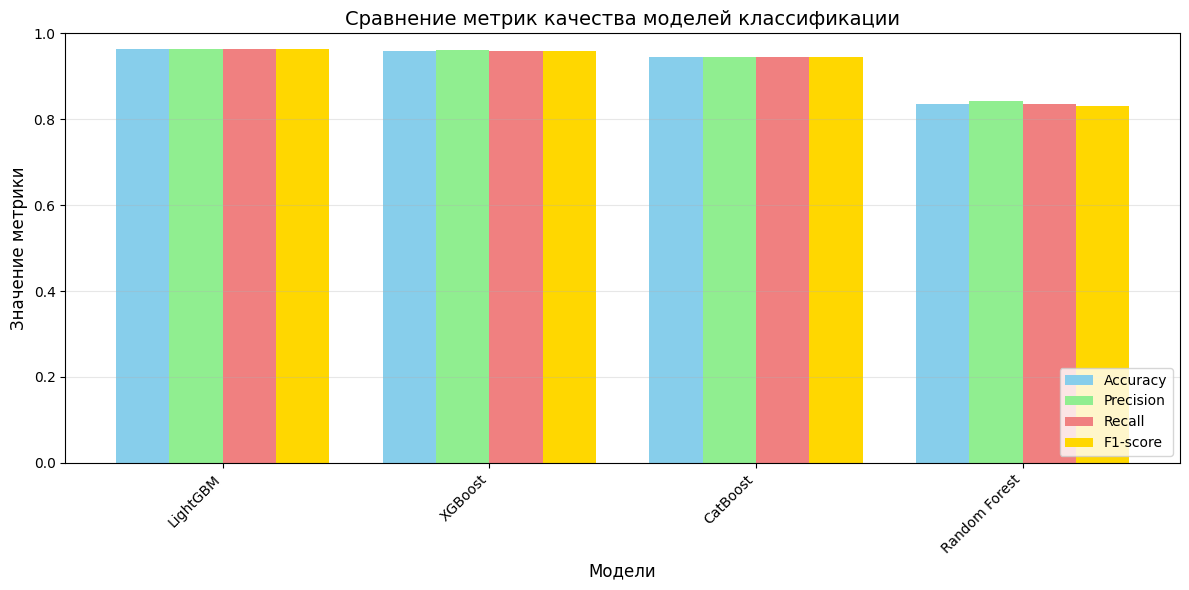

Детальный анализ моделей: LightGBM


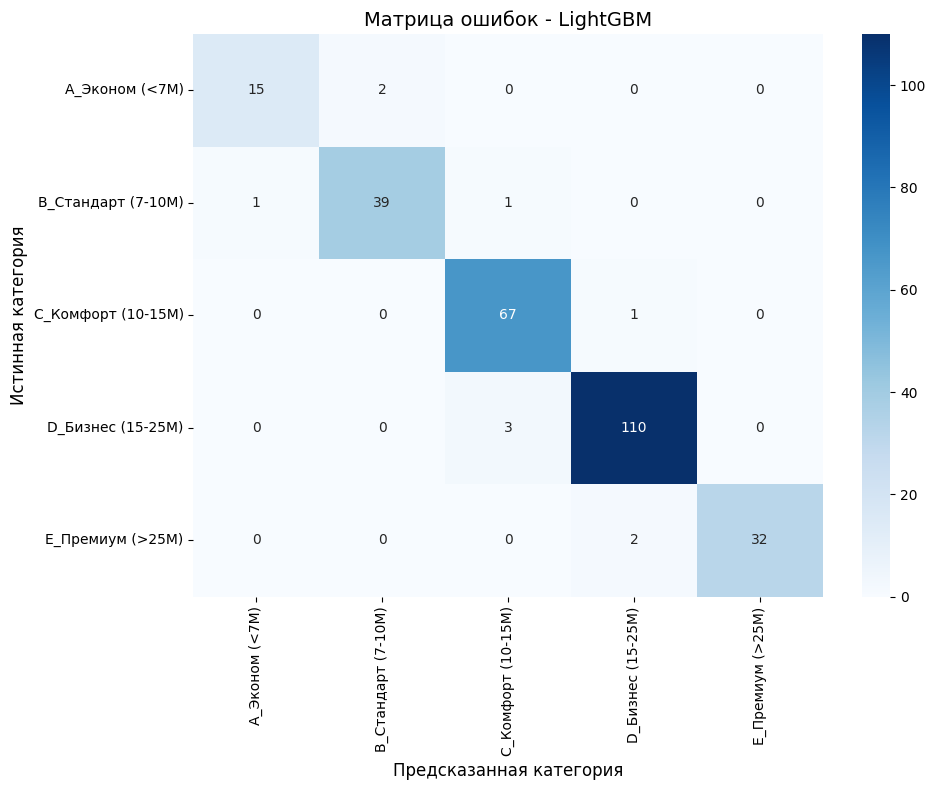


Classification Report для LightGBM:
                    precision    recall  f1-score   support

    A_Эконом (<7M)       0.94      0.88      0.91        17
B_Стандарт (7-10M)       0.95      0.95      0.95        41
C_Комфорт (10-15M)       0.94      0.99      0.96        68
 D_Бизнес (15-25M)       0.97      0.97      0.97       113
  E_Премиум (>25M)       1.00      0.94      0.97        34

          accuracy                           0.96       273
         macro avg       0.96      0.95      0.95       273
      weighted avg       0.96      0.96      0.96       273



In [21]:
print("СРАВНЕНИЕ МОДЕЛЕЙ")

# Создаем DataFrame с результатами
comparison_df = pd.DataFrame({
    'Модель': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision (weighted)': [results[m]['precision'] for m in results],
    'Recall (weighted)': [results[m]['recall'] for m in results],
    'F1-score (weighted)': [results[m]['f1'] for m in results]
}).sort_values('F1-score (weighted)', ascending=False)

print("\nСравнение метрик моделей:")
print(comparison_df.to_string(index=False))

# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.2

ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='skyblue')
ax.bar(x - 0.5*width, comparison_df['Precision (weighted)'], width, label='Precision', color='lightgreen')
ax.bar(x + 0.5*width, comparison_df['Recall (weighted)'], width, label='Recall', color='lightcoral')
ax.bar(x + 1.5*width, comparison_df['F1-score (weighted)'], width, label='F1-score', color='gold')

ax.set_xlabel('Модели', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Сравнение метрик качества моделей классификации', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Модель'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# Определяем лучшую модель по F1-score
best_model_name = comparison_df.iloc[0]['Модель']
best_model = models[best_model_name]
best_y_pred = results[best_model_name]['y_pred']

print(f"Детальный анализ моделей: {best_model_name}")

# Матрица ошибок
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.xlabel('Предсказанная категория', fontsize=12)
plt.ylabel('Истинная категория', fontsize=12)
plt.title(f'Матрица ошибок - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Classification report
print(f"\nClassification Report для {best_model_name}:")
print(classification_report(y_test, best_y_pred, target_names=le_target.classes_))

### 5. Сравнение моделей lightgbm в зависимости от разделения на интервалы

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

df_model = df.copy()
housing = df_model['current_housing'].mode()[0]
df_model['current_housing'].fillna(housing, inplace=True)

print("ИССЛЕДОВАНИЕ ЭФФЕКТИВНОСТИ lightgbm")
print("С РАЗНЫМИ ГРАНИЦАМИ КАТЕГОРИЙ (5 КАТЕГОРИЙ)")

numerical_features = ['max_commute_time', 'metro_priority', 'min_rooms', 'min_area', 'household_size']
categorical_features = ['main_pain', 'preferred_district', 'preferred_floor', 'property_type', 
                        'current_housing', 'marital_status', 'age_group', 'need_parking']
# Добавляем признаки-отношения
df_model['area_per_room'] = df_model['min_area'] / (df_model['min_rooms'] + 1)
df_model['budget_per_person'] = df_model['max_budget'] / df_model['household_size']
df_model['area_per_person'] = df_model['min_area'] / df_model['household_size']

numerical_features.extend(['area_per_room', 'budget_per_person', 'area_per_person'])

budget_stats = df_model['max_budget'].describe()
print(f"\nСтатистика бюджета:")
print(f"  Минимум: {budget_stats['min']:,.0f} руб")
print(f"  25-й перцентиль: {budget_stats['25%']:,.0f} руб")
print(f"  Медиана: {budget_stats['50%']:,.0f} руб")
print(f"  75-й перцентиль: {budget_stats['75%']:,.0f} руб")
print(f"  Максимум: {budget_stats['max']:,.0f} руб")

ИССЛЕДОВАНИЕ ЭФФЕКТИВНОСТИ lightgbm
С РАЗНЫМИ ГРАНИЦАМИ КАТЕГОРИЙ (5 КАТЕГОРИЙ)

Статистика бюджета:
  Минимум: 3,784,158 руб
  25-й перцентиль: 10,723,830 руб
  Медиана: 15,582,448 руб
  75-й перцентиль: 21,112,177 руб
  Максимум: 38,500,962 руб


In [23]:
# Вариант 1: Логические границы (на основе перцентилей и экспертной оценки)
def budget_category_v1(budget):
    if budget < 7_000_000:
        return 'A_Эконом (<7M)'
    elif budget < 10_000_000:
        return 'B_Стандарт (7-10M)'
    elif budget < 15_000_000:
        return 'C_Комфорт (10-15M)'
    elif budget < 25_000_000:
        return 'D_Бизнес (15-25M)'
    else:
        return 'E_Премиум (>25M)'

# Вариант 2: Смещенные вниз (более низкие границы)
def budget_category_v2(budget):
    if budget < 4_000_000:
        return 'A_Эконом (<4M)'
    elif budget < 7_000_000:
        return 'B_Стандарт (4-7M)'
    elif budget < 10_000_000:
        return 'C_Комфорт (7-10M)'
    elif budget < 15_000_000:
        return 'D_Бизнес (10-15M)'
    else:
        return 'E_Премиум (>15M)'

# Вариант 3: Смещенные вверх (более высокие границы)
def budget_category_v3(budget):
    if budget < 10_000_000:
        return 'A_Эконом (<10M)'
    elif budget < 15_000_000:
        return 'B_Стандарт (10-15M)'
    elif budget < 20_000_000:
        return 'C_Комфорт (15-20M)'
    elif budget < 30_000_000:
        return 'D_Бизнес (20-30M)'
    else:
        return 'E_Премиум (>30M)'

# Вариант 4: Равные интервалы (равномерное разбиение)
def budget_category_v4(budget):
    if budget < 5_000_000:
        return 'A_До_5M'
    elif budget < 10_000_000:
        return 'B_5-10M'
    elif budget < 15_000_000:
        return 'C_10-15M'
    elif budget < 20_000_000:
        return 'D_15-20M'
    else:
        return 'E_Более_20M'

# Вариант 5: На основе натуральных логарифмов (логарифмическая шкала)
def budget_category_v5(budget):
    # Логарифмическая шкала лучше отражает восприятие денег
    if budget < 3_000_000:
        return 'A_Очень_низкий (<3M)'
    elif budget < 6_000_000:
        return 'B_Низкий (3-6M)'
    elif budget < 10_000_000:
        return 'C_Средний (6-10M)'
    elif budget < 18_000_000:
        return 'D_Высокий (10-18M)'
    else:
        return 'E_Очень_высокий (>18M)'

# Собираем варианты в словарь
budget_variants = {
    'Вариант 1: Логические границы (7,10,15,25)': budget_category_v1,
    'Вариант 2: Смещенные вниз (4,7,10,15)': budget_category_v2,
    'Вариант 3: Смещенные вверх (10,15,20,30)': budget_category_v3,
    'Вариант 4: Равные интервалы (5,10,15,20)': budget_category_v4,
    'Вариант 5: Логарифмическая шкала (3,6,10,18)': budget_category_v5
}

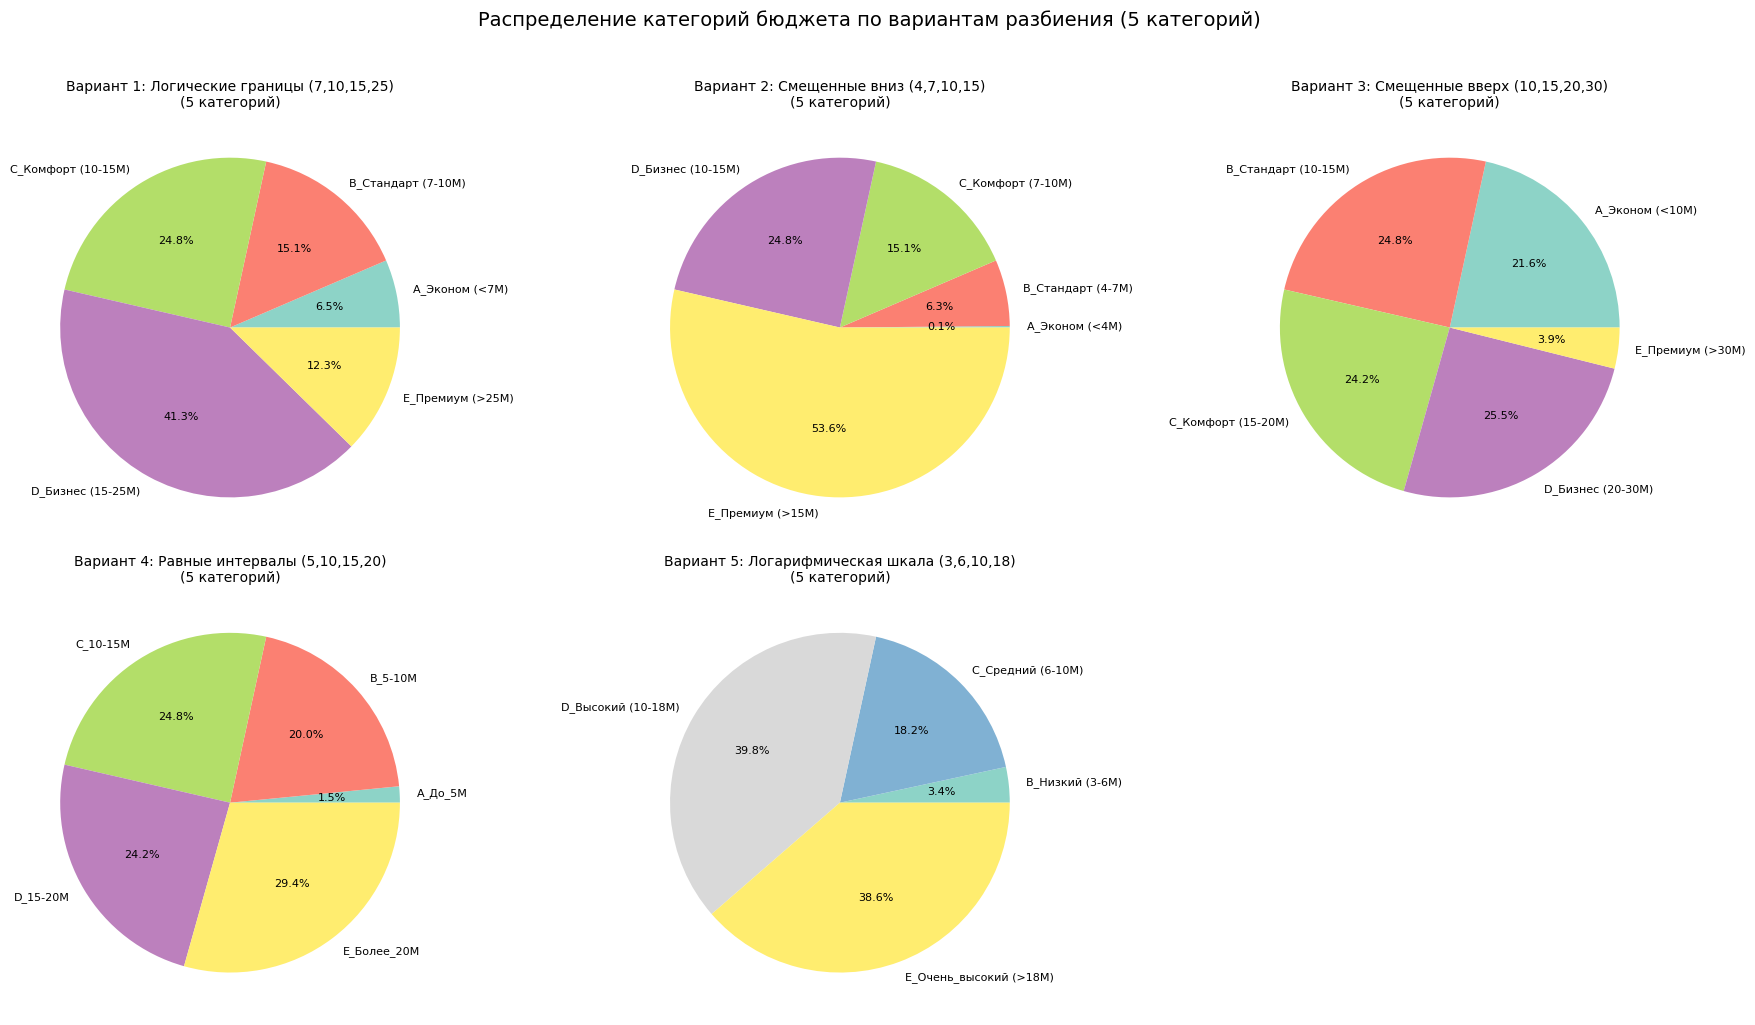

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

distribution_stats = {}

for idx, (variant_name, category_func) in enumerate(budget_variants.items()):
    # Применяем категоризацию
    df_model[f'cat_v{idx+1}'] = df_model['max_budget'].apply(category_func)
    
    # Распределение
    dist = df_model[f'cat_v{idx+1}'].value_counts().sort_index()
    dist_percent = df_model[f'cat_v{idx+1}'].value_counts(normalize=True).sort_index() * 100
    
    distribution_stats[variant_name] = {
        'distribution': dist,
        'min_count': dist.min(),
        'max_count': dist.max(),
        'std_count': dist.std()
    }
        
    # Визуализация
    colors = plt.cm.Set3(np.linspace(0, 1, len(dist)))
    wedges, texts, autotexts = axes[idx].pie(dist.values, labels=dist.index, autopct='%1.1f%%', 
                                              colors=colors, textprops={'fontsize': 8})
    axes[idx].set_title(f'{variant_name}\n(5 категорий)', fontsize=10)

axes[5].axis('off')

plt.suptitle('Распределение категорий бюджета по вариантам разбиения (5 категорий)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import lightgbm as lgb

# Подготовка признаков
X = df_model[numerical_features + categorical_features]

# Словарь для хранения результатов
lgbm_results = {}

for variant_name, category_func in budget_variants.items():
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ: {variant_name}")
    print('='*60)
    
    # Создаем целевую переменную
    y = df_model['max_budget'].apply(category_func)
    
    # Кодируем целевую переменную
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    
    # Разделяем на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Преобразуем категориальные признаки в тип 'category'
    X_train_lgb = X_train.copy()
    X_test_lgb = X_test.copy()
    
    for cat_col in categorical_features:
        X_train_lgb[cat_col] = X_train_lgb[cat_col].astype('category')
        X_test_lgb[cat_col] = X_test_lgb[cat_col].astype('category')
    
    # Создаем dataset для LightGBM
    train_data = lgb.Dataset(X_train_lgb, label=y_train, categorical_feature=categorical_features)
    test_data = lgb.Dataset(X_test_lgb, label=y_test, categorical_feature=categorical_features, reference=train_data)
    
    # Параметры модели
    params = {
        'objective': 'multiclass',
        'num_class': len(le_target.classes_),
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'metric': 'multi_logloss',
        'random_seed': 42,
        'verbose': -1
    }
    
    # Обучаем LightGBM
    lgbm_model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        num_boost_round=100,
        callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False), 
                   lgb.log_evaluation(0)]
    )
    
    # Предсказания
    y_pred_proba = lgbm_model.predict(X_test_lgb)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # КРОСС-ВАЛИДАЦИЯ
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1_scores = []
    
    for train_idx, val_idx in cv_strategy.split(X, y_encoded):
        X_train_cv = X.iloc[train_idx].copy()
        X_val_cv = X.iloc[val_idx].copy()
        y_train_cv = y_encoded[train_idx]
        y_val_cv = y_encoded[val_idx]
        
        # Преобразуем категориальные признаки
        for cat_col in categorical_features:
            X_train_cv[cat_col] = X_train_cv[cat_col].astype('category')
            X_val_cv[cat_col] = X_val_cv[cat_col].astype('category')
        
        # Создаем dataset
        train_cv = lgb.Dataset(X_train_cv, label=y_train_cv, categorical_feature=categorical_features)
        
        # Обучаем модель для каждой fold
        model_cv = lgb.train(
            params,
            train_cv,
            num_boost_round=100,
            callbacks=[lgb.log_evaluation(0)]
        )
        
        y_pred_cv = np.argmax(model_cv.predict(X_val_cv), axis=1)
        cv_f1_scores.append(f1_score(y_val_cv, y_pred_cv, average='weighted', zero_division=0))
    
    cv_mean = np.mean(cv_f1_scores)
    cv_std = np.std(cv_f1_scores)
    
    # Сохраняем результаты
    lgbm_results[variant_name] = {
        'model': lgbm_model,
        'label_encoder': le_target,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'y_test': y_test,
        'y_pred': y_pred,
        'classes': le_target.classes_
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"CV F1-score: {cv_mean:.4f} (+/- {cv_std*2:.4f})")

# Сравнение результатов всех вариантов
print("СРАВНЕНИЕ ВСЕХ ВАРИАНТОВ (LightGBM)")

for variant_name, results in lgbm_results.items():
    print(f"\n {variant_name}:")
    print(f"   F1-score: {results['f1']:.4f}")
    print(f"   CV F1: {results['cv_mean']:.4f} (+/- {results['cv_std']*2:.4f})")
    print(f"   Accuracy: {results['accuracy']:.4f}")

# Лучший вариант
best_variant = max(lgbm_results, key=lambda x: lgbm_results[x]['f1'])
print(f"\nЛучший вариант : {best_variant}")
print(f"   F1-score: {lgbm_results[best_variant]['f1']:.4f}")


ОБУЧЕНИЕ: Вариант 1: Логические границы (7,10,15,25)
Accuracy: 0.9707 (97.07%)
Precision: 0.9711
Recall: 0.9707
F1-score: 0.9707
CV F1-score: 0.9830 (+/- 0.0120)

ОБУЧЕНИЕ: Вариант 2: Смещенные вниз (4,7,10,15)
Accuracy: 0.9780 (97.80%)
Precision: 0.9749
Recall: 0.9780
F1-score: 0.9764
CV F1-score: 0.9839 (+/- 0.0094)

ОБУЧЕНИЕ: Вариант 3: Смещенные вверх (10,15,20,30)
Accuracy: 0.9817 (98.17%)
Precision: 0.9821
Recall: 0.9817
F1-score: 0.9817
CV F1-score: 0.9874 (+/- 0.0121)

ОБУЧЕНИЕ: Вариант 4: Равные интервалы (5,10,15,20)
Accuracy: 0.9780 (97.80%)
Precision: 0.9782
Recall: 0.9780
F1-score: 0.9778
CV F1-score: 0.9867 (+/- 0.0152)

ОБУЧЕНИЕ: Вариант 5: Логарифмическая шкала (3,6,10,18)
Accuracy: 0.9927 (99.27%)
Precision: 0.9927
Recall: 0.9927
F1-score: 0.9927
CV F1-score: 0.9889 (+/- 0.0123)
СРАВНЕНИЕ ВСЕХ ВАРИАНТОВ (LightGBM)

 Вариант 1: Логические границы (7,10,15,25):
   F1-score: 0.9707
   CV F1: 0.9830 (+/- 0.0120)
   Accuracy: 0.9707

 Вариант 2: Смещенные вниз (4,7,10,15):

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Анализ результатов
print("ВЫВОДЫ ПО ИССЛЕДОВАНИЮ ОПТИМАЛЬНЫХ ГРАНИЦ КАТЕГОРИЙ")

# Создание таблицы сравнения
comparison_data = []
for variant_name, results in lgbm_results.items():
    comparison_data.append({
        'Вариант': variant_name,
        'Accuracy': results.get('accuracy', results.get('Accuracy', 0)),
        'Precision': results.get('precision', results.get('Precision', 0)),
        'Recall': results.get('recall', results.get('Recall', 0)),
        'F1-score': results.get('f1', results.get('F1', 0)),
        'CV_F1_mean': results.get('cv_mean', results.get('CV_mean', 0)),
        'CV_F1_std': results.get('cv_std', results.get('CV_std', 0))
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('F1-score', ascending=False).reset_index(drop=True)

best_row = comparison_df.iloc[0]
worst_row = comparison_df.iloc[-1]

print(f"\nЛУЧШИЙ ВАРИАНТ: {best_row['Вариант']}")
print(f"F1-score: {best_row['F1-score']:.4f} ({best_row['F1-score']*100:.2f}%)")
print(f"\nХУДШИЙ ВАРИАНТ: {worst_row['Вариант']}")
print(f"F1-score: {worst_row['F1-score']:.4f} ({worst_row['F1-score']*100:.2f}%)")

if worst_row['F1-score'] > 0:
    improvement = (best_row['F1-score'] - worst_row['F1-score']) / worst_row['F1-score'] * 100
    print(f"\nУЛУЧШЕНИЕ: +{improvement:.1f}% по F1-score")

print(f"\nРЕКОМЕНДАЦИЯ: Использовать '{best_row['Вариант']}' для репрайсинга")

ВЫВОДЫ ПО ИССЛЕДОВАНИЮ ОПТИМАЛЬНЫХ ГРАНИЦ КАТЕГОРИЙ

ЛУЧШИЙ ВАРИАНТ: Вариант 5: Логарифмическая шкала (3,6,10,18)
F1-score: 0.9927 (99.27%)

ХУДШИЙ ВАРИАНТ: Вариант 1: Логические границы (7,10,15,25)
F1-score: 0.9707 (97.07%)

УЛУЧШЕНИЕ: +2.3% по F1-score

РЕКОМЕНДАЦИЯ: Использовать 'Вариант 5: Логарифмическая шкала (3,6,10,18)' для репрайсинга


### 6. Анализ округов

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_analysis = df.copy()

housing = df_analysis['current_housing'].mode()[0]
df_analysis['current_housing'].fillna(housing, inplace=True)

print("АНАЛИЗ ПРЕДПОЧИТАЕМЫХ ОКРУГОВ")
print("\n1. РАСПРЕДЕЛЕНИЕ ПРЕДПОЧИТАЕМЫХ ОКРУГОВ")

district_dist = df_analysis['preferred_district'].value_counts()
district_percent = df_analysis['preferred_district'].value_counts(normalize=True) * 100

district_stats = pd.DataFrame({
    'Количество': district_dist,
    'Процент': district_percent.round(1)
})
print(district_stats)

АНАЛИЗ ПРЕДПОЧИТАЕМЫХ ОКРУГОВ

1. РАСПРЕДЕЛЕНИЕ ПРЕДПОЧИТАЕМЫХ ОКРУГОВ
                          Количество  Процент
preferred_district                           
СВАО                             184     13.5
ВАО                              174     12.8
ЮАО                              171     12.6
САО                              167     12.3
ЮВАО                             163     12.0
ЮЗАО                             139     10.2
ЗАО                              100      7.3
СЗАО                              86      6.3
ЦАО                               68      5.0
Новая Москва (ТАО)                61      4.5
Московская область                34      2.5
Пока не определился(ась)          15      1.1


ТОП-5 САМЫХ ПОПУЛЯРНЫХ ОКРУГОВ:
   1. СВАО: 184 чел. (13.5%)
   2. ВАО: 174 чел. (12.8%)
   3. ЮАО: 171 чел. (12.6%)
   4. САО: 167 чел. (12.3%)
   5. ЮВАО: 163 чел. (12.0%)


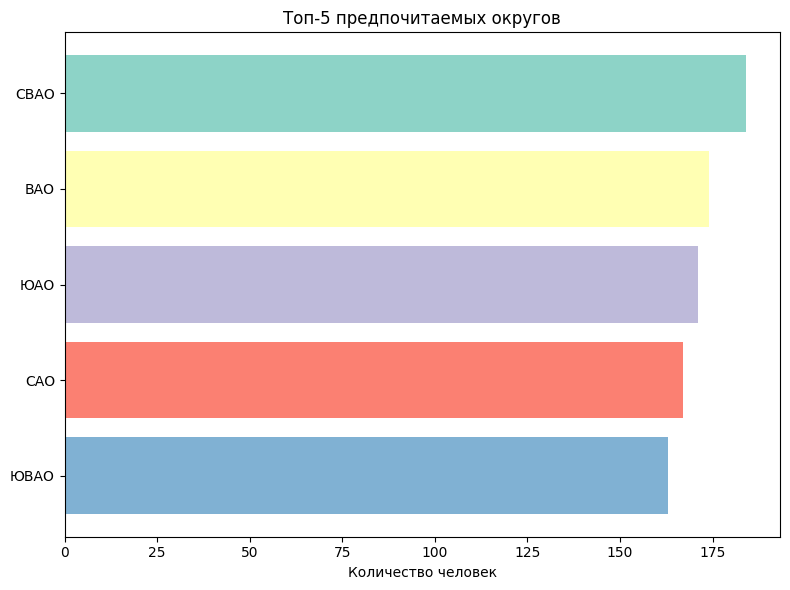

ОЖИДАЕМЫЕ ЦЕНЫ (на основе ответов респондентов):

Ожидаемый бюджет (млн руб) по округам:
                          min_million  mean_million  max_million  count
preferred_district                                                     
ЦАО                               8.0          20.4         37.3     68
ЮЗАО                              5.0          17.1         33.9    139
САО                               5.2          17.1         35.1    167
ЗАО                               4.5          16.9         37.9    100
СЗАО                              5.4          16.8         35.4     86
ЮАО                               4.2          16.8         36.2    171
СВАО                              3.8          16.4         35.2    184
ЮВАО                              4.2          15.7         38.5    163
ВАО                               4.1          15.2         35.2    174
Новая Москва (ТАО)                3.9          13.8         29.8     61
Пока не определился(ась)          5.4          

In [28]:
print("ТОП-5 САМЫХ ПОПУЛЯРНЫХ ОКРУГОВ:")

top5_districts = district_dist.head(5)
for i, (district, count) in enumerate(top5_districts.items(), 1):
    print(f"   {i}. {district}: {count} чел. ({district_percent[district]:.1f}%)")

# Визуализация топ-5
plt.figure(figsize=(8, 6))
colors = plt.cm.Set3(range(len(top5_districts)))
plt.barh(range(len(top5_districts)), top5_districts.values, color=colors)
plt.yticks(range(len(top5_districts)), top5_districts.index)
plt.xlabel('Количество человек')
plt.title('Топ-5 предпочитаемых округов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("ОЖИДАЕМЫЕ ЦЕНЫ (на основе ответов респондентов):")

expected_prices = df_analysis.groupby('preferred_district')['max_budget'].agg(['min', 'mean', 'max', 'count'])
expected_prices['mean_million'] = expected_prices['mean'] / 1_000_000
expected_prices['min_million'] = expected_prices['min'] / 1_000_000
expected_prices['max_million'] = expected_prices['max'] / 1_000_000
expected_prices = expected_prices.sort_values('mean', ascending=False)

print("\nОжидаемый бюджет (млн руб) по округам:")
print(expected_prices[['min_million', 'mean_million', 'max_million', 'count']].round(1).to_string())

In [29]:
print("РЕАЛЬНЫЕ РЫНОЧНЫЕ ЦЕНЫ (данные IRN.RU, октябрь 2025):")

# Данные по округам Москвы (цена за кв.м, тыс. руб) в КОРОТКИХ названиях (как в опросе)
real_prices_per_sqm = {
    'ЦАО': 437.5,
    'ЗАО': 320.2,
    'ЮЗАО': 316.8,
    'САО': 291.2,
    'СЗАО': 290.2,
    'ЮАО': 256.2,
    'СВАО': 253.3,
    'ВАО': 250.0,
    'ЮВАО': 239.7,
    'Зеленоград': 208.2,
    'Новая Москва (ТАО)': 210.3,
    'Троицкий': 179.8
}

# Средняя площадь квартиры из опроса
avg_area = df_analysis['min_area'].mean()

# Рассчитываем реальную стоимость квартиры (уже с короткими названиями)
real_prices = {}
for district, price_sqm in real_prices_per_sqm.items():
    real_prices[district] = {
        'min_million': (price_sqm * 30) / 1000,      # 30 кв.м — студия/1-комн
        'mean_million': (price_sqm * avg_area) / 1000, # средняя желаемая площадь
        'max_million': (price_sqm * 65) / 1000,      # 65 кв.м — 2-3 комнаты
        'price_per_sqm': price_sqm
    }

real_df = pd.DataFrame(real_prices).T
real_df = real_df.round(1)

print(f"\nСредняя желаемая площадь из опроса: {avg_area:.0f} кв.м\n")
print("Реальная рыночная стоимость квартиры по округам (млн руб):")
print(real_df[['min_million', 'mean_million', 'max_million']].to_string())

print("СРАВНЕНИЕ: ОЖИДАНИЯ vs РЕАЛЬНОСТЬ")

comparison = []
for district in expected_prices.index:
    # Пропускаем "Пока не определился(ась)" и "Московская область"
    if district in ['Пока не определился(ась)', 'Московская область']:
        continue
    
    # Теперь названия уже совпадают (короткие)
    if district in real_prices:
        expected = expected_prices.loc[district, 'mean_million']
        real = real_prices[district]['mean_million']
        diff = real - expected
        diff_percent = (diff / expected) * 100 if expected > 0 else 0
        
        comparison.append({
            'Округ': district,
            'Ожидаемый бюджет': expected,
            'Реальный бюджет': real,
            'Разница (млн)': diff,
            'Разница (%)': diff_percent
        })

РЕАЛЬНЫЕ РЫНОЧНЫЕ ЦЕНЫ (данные IRN.RU, октябрь 2025):

Средняя желаемая площадь из опроса: 64 кв.м

Реальная рыночная стоимость квартиры по округам (млн руб):
                    min_million  mean_million  max_million
ЦАО                        13.1          27.8         28.4
ЗАО                         9.6          20.4         20.8
ЮЗАО                        9.5          20.1         20.6
САО                         8.7          18.5         18.9
СЗАО                        8.7          18.4         18.9
ЮАО                         7.7          16.3         16.7
СВАО                        7.6          16.1         16.5
ВАО                         7.5          15.9         16.2
ЮВАО                        7.2          15.2         15.6
Зеленоград                  6.2          13.2         13.5
Новая Москва (ТАО)          6.3          13.4         13.7
Троицкий                    5.4          11.4         11.7
СРАВНЕНИЕ: ОЖИДАНИЯ vs РЕАЛЬНОСТЬ



Результаты сравнения (от самого дорогого к самому доступному):
             Округ  Ожидаемый бюджет  Реальный бюджет  Разница (млн)  Разница (%)
               ЦАО         20.375094        27.814336       7.439241    36.511446
               ЗАО         16.877527        20.356915       3.479388    20.615508
              ЮЗАО         17.121402        20.140758       3.019355    17.634978
              СЗАО         16.816043        18.449646       1.633603     9.714550
               САО         17.081655        18.513222       1.431567     8.380729
               ВАО         15.198546        15.893906       0.695360     4.575172
              СВАО         16.374998        16.103706      -0.271292    -1.656745
Новая Москва (ТАО)         13.750358        13.369954      -0.380405    -2.766507
              ЮВАО         15.707996        15.239077      -0.468919    -2.985226
               ЮАО         16.761606        16.288075      -0.473531    -2.825094


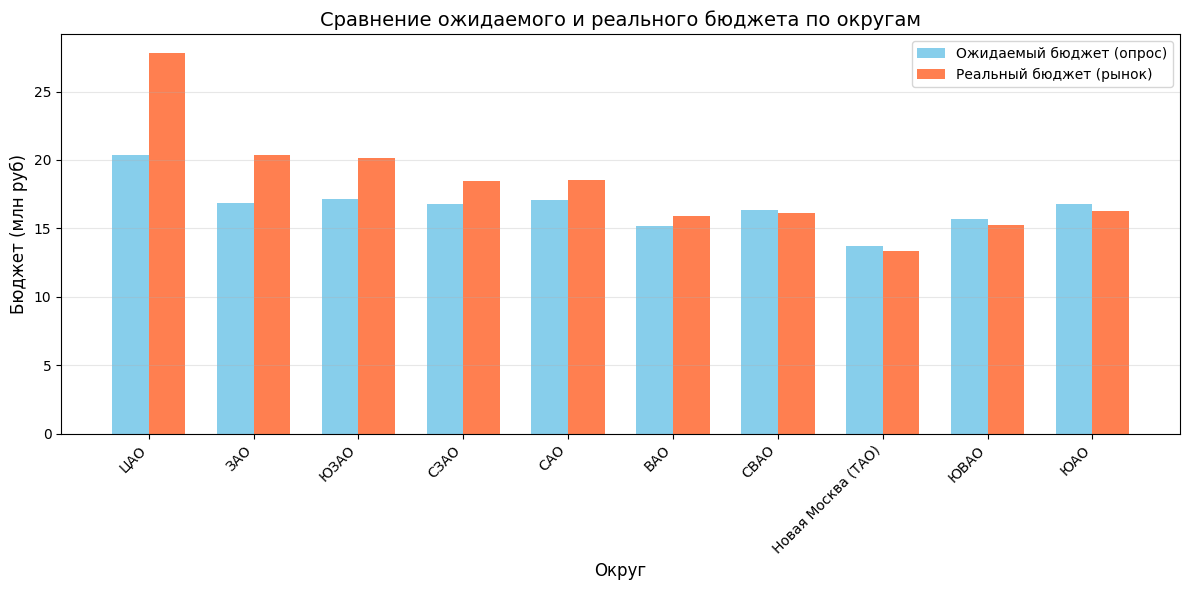

Ключевые выводы:

1. САМЫЙ ПОПУЛЯРНЫЙ ОКРУГ: СВАО (184 чел., 13.5%)

2. САМЫЕ ДОРОГИЕ ОКРУГА ПО ОЖИДАНИЯМ:
   • ЦАО: 20.4 млн руб
   • ЮЗАО: 17.1 млн руб
   • САО: 17.1 млн руб

3. САМЫЕ ДОСТУПНЫЕ ОКРУГА ПО ОЖИДАНИЯМ:
   • Новая Москва (ТАО): 13.8 млн руб

4. РАЗРЫВ МЕЖДУ ОЖИДАНИЯМИ И РЕАЛЬНОСТЬЮ:
   • Наибольший разрыв (реальность ДОРОЖЕ): ЦАО (+7.4 млн руб, +37%)
   • Самый доступный по сравнению с ожиданиями: ЮАО (реальность на 0.5 млн руб ДЕШЕВЛЕ)

5. ОБЩАЯ КАРТИНА:
   • Средний ожидаемый бюджет: 16.6 млн руб
   • Средний реальный бюджет: 18.2 млн руб
   • Разрыв: +1.6 млн руб (реальность на 10% дороже)

   В среднем реальные цены ПРЕВЫШАЮТ ожидания респондентов на 1.6 млн руб


In [30]:
if len(comparison) > 0:
    comp_df = pd.DataFrame(comparison)
    comp_df = comp_df.sort_values('Разница (млн)', ascending=False)
    
    print("\nРезультаты сравнения (от самого дорогого к самому доступному):")
    print(comp_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 6))
    
    districts = comp_df['Округ'].values
    expected_budgets = comp_df['Ожидаемый бюджет'].values
    real_budgets = comp_df['Реальный бюджет'].values
    
    x = np.arange(len(districts))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, expected_budgets, width, label='Ожидаемый бюджет (опрос)', color='skyblue')
    bars2 = ax.bar(x + width/2, real_budgets, width, label='Реальный бюджет (рынок)', color='coral')
    
    ax.set_xlabel('Округ', fontsize=12)
    ax.set_ylabel('Бюджет (млн руб)', fontsize=12)
    ax.set_title('Сравнение ожидаемого и реального бюджета по округам', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(districts, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

    print("Ключевые выводы:")
    
    print(f"\n1. САМЫЙ ПОПУЛЯРНЫЙ ОКРУГ: {top5_districts.index[0]} ({top5_districts.iloc[0]} чел., {district_percent[top5_districts.index[0]]:.1f}%)")
    
    print(f"\n2. САМЫЕ ДОРОГИЕ ОКРУГА ПО ОЖИДАНИЯМ:")
    for district, budget in expected_prices.head(3)[['mean_million']].iterrows():
        if district not in ['Пока не определился(ась)', 'Московская область']:
            print(f"   • {district}: {budget['mean_million']:.1f} млн руб")
    
    print(f"\n3. САМЫЕ ДОСТУПНЫЕ ОКРУГА ПО ОЖИДАНИЯМ:")
    for district, budget in expected_prices.tail(3)[['mean_million']].iterrows():
        if district not in ['Пока не определился(ась)', 'Московская область']:
            print(f"   • {district}: {budget['mean_million']:.1f} млн руб")
    
    print(f"\n4. РАЗРЫВ МЕЖДУ ОЖИДАНИЯМИ И РЕАЛЬНОСТЬЮ:")
    worst_gap = comp_df.loc[comp_df['Разница (млн)'].idxmax()]
    best_gap = comp_df.loc[comp_df['Разница (млн)'].idxmin()]
    
    if worst_gap['Разница (млн)'] > 0:
        print(f"   • Наибольший разрыв (реальность ДОРОЖЕ): {worst_gap['Округ']} (+{worst_gap['Разница (млн)']:.1f} млн руб, +{worst_gap['Разница (%)']:.0f}%)")
    else:
        print(f"   • Наибольший разрыв (реальность ДЕШЕВЛЕ): {worst_gap['Округ']} ({worst_gap['Разница (млн)']:.1f} млн руб, {worst_gap['Разница (%)']:.0f}%)")
    
    if best_gap['Разница (млн)'] < 0:
        print(f"   • Самый доступный по сравнению с ожиданиями: {best_gap['Округ']} (реальность на {abs(best_gap['Разница (млн)']):.1f} млн руб ДЕШЕВЛЕ)")
    else:
        print(f"   • Самый дорогой по сравнению с ожиданиями: {best_gap['Округ']} (реальность на {best_gap['Разница (млн)']:.1f} млн руб ДОРОЖЕ)")
    
    print(f"\n5. ОБЩАЯ КАРТИНА:")
    avg_expected = comp_df['Ожидаемый бюджет'].mean()
    avg_real = comp_df['Реальный бюджет'].mean()
    print(f"   • Средний ожидаемый бюджет: {avg_expected:.1f} млн руб")
    print(f"   • Средний реальный бюджет: {avg_real:.1f} млн руб")
    
    if avg_real > avg_expected:
        print(f"   • Разрыв: +{avg_real - avg_expected:.1f} млн руб (реальность на {((avg_real/avg_expected)-1)*100:.0f}% дороже)")
        print(f"\n   В среднем реальные цены ПРЕВЫШАЮТ ожидания респондентов на {avg_real - avg_expected:.1f} млн руб")
    else:
        print(f"   • Разрыв: {avg_expected - avg_real:.1f} млн руб (реальность на {((avg_expected/avg_real)-1)*100:.0f}% дешевле)")
        print(f"\n   В среднем реальные цены НИЖЕ ожиданий респондентов на {avg_expected - avg_real:.1f} млн руб")

else:
    print("\nНет данных для сравнения")

### предобработка текста

АНАЛИЗ ТЕКСТОВЫХ ОТВЕТОВ (relocation_reason_text)

1. Векторизация текстов с помощью TF-IDF...
   Сформировано 200 текстовых признаков
   Обработано 1362 текстовых ответов

2. Определение оптимального числа кластеров (метод локтя)...


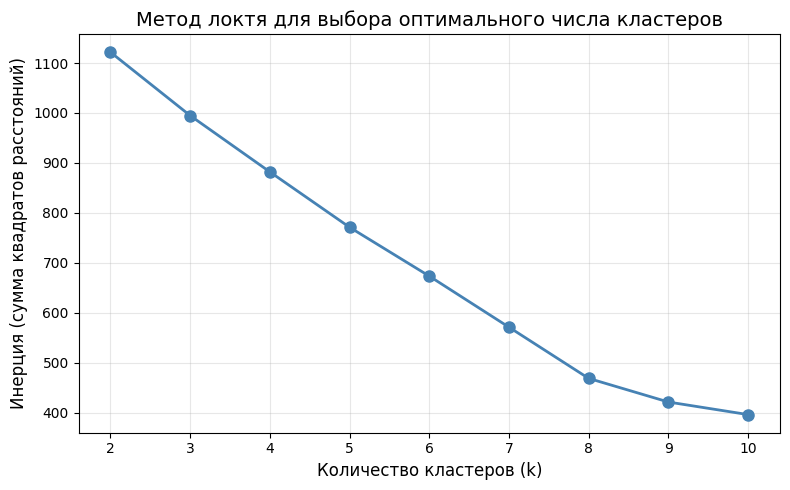


   Оптимальное количество кластеров: 10


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Подготовка данных
df_analysis = df.copy()

# Заполняем пропуски в текстах
df_analysis['jtbd_reason_text'] = df_analysis['jtbd_reason_text'].fillna('')

#стоп-слова
stop_words = [
    'это', 'этот', 'эта', 'эти', 'этом', 'этой', 'этого', 'этому', 'этим',
    'так', 'такой', 'такая', 'такие', 'такого', 'такому', 'таким',
    'вот', 'просто', 'очень', 'немного', 'совсем', 'чуть', 'почти',
    'когда', 'тогда', 'потом', 'сейчас', 'всегда', 'иногда',
    'там', 'тут', 'здесь', 'везде', 'нигде', 'кое-где',
    'можно', 'нужно', 'надо', 'хочется', 'хочет', 'хотят',
    'сказать', 'говорить', 'думаю', 'кажется', 'знаю', 'понимаю',
    'жить', 'хочу', 'ищу', 'смотрю', 'планирую', 'меня', 'мене',
    'квартиру', 'квартира', 'квартиры', 'жилье', 'жилья', 'дом', 'дома',
    'есть', 'было', 'будет', 'быть', 'без', 'для', 'про', 'уже', 'вариант', 'купил', 'нужна', 'хотим', 'комната', 
    'или', 'из'
]

print("АНАЛИЗ ТЕКСТОВЫХ ОТВЕТОВ (relocation_reason_text)")

# TF-IDF векторизация
print("\n1. Векторизация текстов с помощью TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=3,
    max_df=0.8,
    stop_words=stop_words,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(df_analysis['jtbd_reason_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"   Сформировано {tfidf_matrix.shape[1]} текстовых признаков")
print(f"   Обработано {len(df_analysis)} текстовых ответов")

# Определение оптимального числа кластеров (метод локтя)
print("\n2. Определение оптимального числа кластеров (метод локтя)...")

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(tfidf_matrix)
    inertias.append(kmeans_test.inertia_)

# График метода локтя
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
plt.title('Метод локтя для выбора оптимального числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# Выбираем оптимальное k
optimal_k = 10
print(f"\n   Оптимальное количество кластеров: {optimal_k}")

In [32]:
# KMeans кластеризация
print("\nРазбиение на кластеры с помощью KMeans...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

df_analysis['cluster'] = clusters

print(f"\n   Результат разбиения на {optimal_k} кластера:")
for i in range(optimal_k):
    count = (clusters == i).sum()
    percent = count / len(df_analysis) * 100
    print(f"   Кластер {i}: {count} человек ({percent:.1f}%)")

# Топ-5 характерных слов для каждого кластера
print("ТОП-5 ХАРАКТЕРНЫХ СЛОВ ДЛЯ КАЖДОГО КЛАСТЕРА:")

for cluster in range(optimal_k):
    cluster_mask = (clusters == cluster)
    cluster_docs = tfidf_matrix[cluster_mask]
    
    if cluster_docs.shape[0] > 0:
        mean_tfidf = cluster_docs.mean(axis=0).A1
        top_indices = mean_tfidf.argsort()[-5:][::-1]
        top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices if mean_tfidf[i] > 0]
        
        print(f"\n🔹 КЛАСТЕР {cluster} ({cluster_mask.sum()} человек):")
        print("   Характерные слова (топ-5):")
        for i, (word, score) in enumerate(top_words, 1):
            print(f"      {i}. {word} (важность: {score:.4f})")
    else:
        print(f"\n🔹 КЛАСТЕР {cluster}: нет данных")

# Характерные черты каждого кластера
print("ХАРАКТЕРНЫЕ ЧЕРТЫ КАЖДОГО КЛАСТЕРА:")

for cluster in range(optimal_k):
    cluster_data = df_analysis[df_analysis['cluster'] == cluster]
    
    print(f"\n🔹 КЛАСТЕР {cluster}:")
    print(f"   Количество: {len(cluster_data)} человек")
    
    # Средний бюджет
    avg_budget = cluster_data['max_budget'].mean() / 1_000_000
    print(f"   Средний бюджет: {avg_budget:.1f} млн руб")
    
    # Среднее время в пути
    avg_commute = cluster_data['max_commute_time'].mean()
    print(f"   Среднее время в пути: {avg_commute:.0f} мин")
    
    # Важность метро
    avg_metro = cluster_data['metro_priority'].mean()
    print(f"   Важность метро: {avg_metro:.1f}/5")
    
    # Размер семьи
    avg_household = cluster_data['household_size'].mean()
    print(f"   Размер семьи: {avg_household:.1f} чел")
    
    # Основная боль (самая частая)
    top_pain = cluster_data['main_pain'].mode()
    if len(top_pain) > 0:
        print(f"   Основная проблема: {top_pain[0]}")
    
    # Возрастная группа (самая частая)
    top_age = cluster_data['age_group'].mode()
    if len(top_age) > 0:
        print(f"   Возраст: {top_age[0]}")

# ИТОГОВЫЙ ВЫВОД
print("ВЫВОД:")

print("""
По текстовому ответу (jtbd_reason_text) ДЕЙСТВИТЕЛЬНО можно определить 
характеристики человека. Каждый кластер имеет свой уникальный набор слов:

""")

for cluster in range(optimal_k):
    cluster_mask = (clusters == cluster)
    cluster_docs = tfidf_matrix[cluster_mask]
    if cluster_docs.shape[0] > 0:
        mean_tfidf = cluster_docs.mean(axis=0).A1
        top_indices = mean_tfidf.argsort()[-5:][::-1]
        top_words = [feature_names[i] for i in top_indices if mean_tfidf[i] > 0]
        print(f"Кластер {cluster}: {', '.join(top_words)}")
        print()

print("Таким образом, по ключевым словам в тексте можно понять,\n"
      "  с какой проблемой столкнулся человек и какой у него портрет.")


Разбиение на кластеры с помощью KMeans...

   Результат разбиения на 10 кластера:
   Кластер 0: 137 человек (10.1%)
   Кластер 1: 406 человек (29.8%)
   Кластер 2: 143 человек (10.5%)
   Кластер 3: 127 человек (9.3%)
   Кластер 4: 122 человек (9.0%)
   Кластер 5: 120 человек (8.8%)
   Кластер 6: 117 человек (8.6%)
   Кластер 7: 26 человек (1.9%)
   Кластер 8: 57 человек (4.2%)
   Кластер 9: 107 человек (7.9%)
ТОП-5 ХАРАКТЕРНЫХ СЛОВ ДЛЯ КАЖДОГО КЛАСТЕРА:

🔹 КЛАСТЕР 0 (137 человек):
   Характерные слова (топ-5):
      1. потише (важность: 0.3070)
      2. то потише (важность: 0.3051)
      3. надоел (важность: 0.3013)
      4. шумный (важность: 0.3010)
      5. район что (важность: 0.2995)

🔹 КЛАСТЕР 1 (406 человек):
   Характерные слова (топ-5):
      1. ищем (важность: 0.0577)
      2. хорошей (важность: 0.0520)
      3. звукоизоляцией (важность: 0.0396)
      4. ищем хорошей (важность: 0.0380)
      5. хорошей звукоизоляцией (важность: 0.0380)

🔹 КЛАСТЕР 2 (143 человек):
   Характерн